In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/metadata.csv
/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/B0049.mat
/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/B0043.mat
/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/B0006.mat
/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/B0032.mat
/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/B0005.mat
/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/B0039.mat
/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/B0040.mat
/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe/Battery_DataSet/Battery_DataSet/README_49_50_51_52.txt

In [2]:
# ============================================================
# MULTIMODAL BATTERY SOH ESTIMATION
# Using Thermal Imaging + CSV/PV Features
# FusionModelV2 — Cross-Modal Attention with Intermediate Gating
# ============================================================
#
# PROJECT OVERVIEW
# ----------------
# This notebook implements a multimodal deep learning pipeline for
# estimating the State of Health (SoH) of Li-ion batteries in a
# photovoltaic (PV) context. SoH is defined as the ratio of current
# capacity to nominal capacity, ranging from 1.0 (new) to ~0.25
# (end-of-life).
#
# TWO MODALITIES ARE FUSED:
#   1. Thermal images (64×64) — synthetically generated from
#      electrochemical parameters extracted from NASA PCOe .mat files.
#      Hot zones, peripheral defects, and thermal gradients are
#      physically motivated by degradation mechanisms (SEI growth,
#      lithium plating, impedance rise).
#   2. CSV/PV tabular features (25 variables) — raw electrical
#      measurements (temperature, voltage, current, capacity) enriched
#      with engineered features (rolling stats, fade rate, estimated
#      internal resistance) and synthetic PV irradiance profiles
#      (seasonal current, surface temperature, variability index).
#
# ARCHITECTURE: FusionModelV2
#   - ThermalCNN         : 4-block CNN → 64-dim image embedding
#   - BatteryLSTM        : 2-layer LSTM → 64-dim feature embedding
#   - IntermediateFusionGate : cross-modal gating BEFORE attention
#                              (each modality conditions the other via sigmoid gates)
#   - CrossModalAttention : multi-head attention on already-gated embeddings
#   - Prediction head    : 128 → 256 → 128 → 64 → 1 (SoH ∈ [0,1])
#
# PIPELINE SUMMARY (cells 1–19):
#   Cell  1 — Imports & device setup
#   Cell  2 — Data loading from NASA PCOe .mat files + SoH computation
#   Cell  3 — Synthetic thermal image generation (physics-based, 64×64)
#   Cell  4 — Synthetic PV profiles (seasonal, cloud, shading)
#   Cell  5 — Feature engineering (15 CSV + 10 PV = 25 features)
#   Cell  6 — Train / Val / Test split (battery-level, no leakage)
#   Cell  7 — Fast dataset (images pre-loaded in RAM) + DataLoaders
#   Cell  8 — FusionModelV2 architecture (intermediate fusion + cross-attn)
#   Cell  9 — Training loop (AdamW + Huber loss + CosineAnnealing + EarlyStopping)
#   Cell 10 — Training curves (loss + MAE%)
#   Cell 11 — Test set evaluation (MAE, RMSE, R², MAPE + scatter + error hist)
#   Cell 13 — Multimodal XAI (SHAP + attention gates + contribution decomposition + t-SNE)
#   Cell 14 — Anomaly detection (thermal score + degradation threshold)
#   Cell 15 — Ablation study (CSV-only vs Image-only vs Fusion)
#   Cell 16 — Baseline comparison (Ridge / RF / GBM / SVR vs FusionModelV2)
#   Cell 17 — Per-battery degradation curves (cycle-by-cycle tracking)
#   Cell 18 — Replacement threshold classifier (SoH < 0.8: ROC, PR, confusion matrix)
#   Cell 19 — Uncertainty estimation (Monte Carlo Dropout, 50 forward passes)
#
# KEY DESIGN DECISIONS
# --------------------
# • Battery-level split: all cycles of one battery stay in the same
#   split. This prevents data leakage and gives realistic generalisation.
# • Huber loss (δ=0.05): robust to outliers while remaining differentiable,
#   better suited than MSE for the heavy-tailed SoH error distribution.
# • Intermediate fusion gate: gating BEFORE cross-attention forces the
#   model to learn cross-modal conditioning at the representation level,
#   not just the attention level. The residual + LayerNorm design ensures
#   stable gradients.
# • Grad-CAM is not used here (no spatial output needed for tabular branch).
#   Instead, three complementary XAI methods are used: SHAP (feature level),
#   attention gate analysis (fusion level), and ablation-style contribution
#   decomposition (modality level).
# ============================================================


# ============================================================
# CELL 1 — IMPORTS & DEVICE SETUP
# ============================================================
# Standard scientific stack + PyTorch + sklearn utilities.
# device = cpu (Kaggle CPU kernel; change to 'cuda' if GPU available).
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
import os, time, copy, joblib
from pathlib import Path
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

device = torch.device('cpu')
print(f"Device : {device}")

# Dataset location on Kaggle
dataset_path = '/kaggle/input/datasets/ckskaggle/li-ion-battery-dataset-from-nasa-pcoe'
files = list(Path(dataset_path).rglob('*.mat'))
print(f"✓ Fichiers .mat : {len(files)}")
for f in files[:5]:
    print(f"  - {f.name}")

Device : cpu
✓ Fichiers .mat : 34
  - B0049.mat
  - B0043.mat
  - B0006.mat
  - B0032.mat
  - B0005.mat


In [3]:
# ============================================================
# CELL 2 — DATA LOADING + SoH COMPUTATION
# ============================================================
# Loads NASA PCOe .mat files. Each file contains one battery's full
# cycle history. Only discharge cycles are kept (charge cycles lack
# the capacity measurement needed for SoH).
#
# SoH = capacity / max_capacity, clipped to [0.25, 1.00].
# Batteries with fewer than ~10 valid cycles are implicitly discarded
# (they contribute no useful temporal signal).
#
# Extracted per-cycle features:
#   temp_mean / temp_max / temp_std — thermal profile
#   voltage_mean / voltage_min       — voltage window
#   current_mean                     — average discharge current (A)
#   capacity                         — measured discharged Ah
# ============================================================

def load_battery_mat(filepath):
    try:
        mat  = sio.loadmat(filepath, simplify_cells=True)
        key  = [k for k in mat.keys() if not k.startswith('_')][0]
        data = mat[key]
        cycles = data['cycle']
        if isinstance(cycles, dict):
            cycles = [cycles]
        records = []
        for i, cycle in enumerate(cycles):
            try:
                if cycle['type'] != 'discharge':
                    continue
                cd      = cycle['data']
                temp    = cd.get('Temperature_measured', [])
                voltage = cd.get('Voltage_measured', [])
                current = cd.get('Current_measured', [])
                cap     = cd.get('Capacity', np.nan)
                if len(temp) == 0 or len(voltage) == 0 or len(current) == 0:
                    continue
                cap_val = float(cap) if not isinstance(cap, np.ndarray) \
                          else float(cap.flat[0])
                records.append({
                    'cycle_index' : i,
                    'temp_mean'   : float(np.mean(temp)),
                    'temp_max'    : float(np.max(temp)),
                    'temp_std'    : float(np.std(temp)),
                    'voltage_mean': float(np.mean(voltage)),
                    'voltage_min' : float(np.min(voltage)),
                    'current_mean': float(np.mean(current)),
                    'capacity'    : cap_val,
                })
            except:
                continue
        return pd.DataFrame(records)
    except Exception as e:
        print(f"✗ Erreur {filepath}: {e}")
        return pd.DataFrame()

print("="*60)
print("CHARGEMENT DES DONNÉES")
print("="*60)

all_dfs = []
for f in files:
    try:
        df = load_battery_mat(str(f))
        if df.empty:
            continue
        df['battery_id'] = f.stem
        nom       = df['capacity'].max()
        df['SoH'] = (df['capacity'] / nom).clip(0, 1)
        all_dfs.append(df)
        print(f"✓ {f.stem} — {len(df)} cycles — "
              f"SoH: {df['SoH'].min():.3f}→{df['SoH'].max():.3f}")
    except Exception as e:
        print(f"✗ {f.stem} — {e}")

master_df = pd.concat(all_dfs, ignore_index=True)
master_df = master_df[
    (master_df['SoH'] >= 0.25) &
    (master_df['SoH'] <= 1.00) &
    (master_df['capacity'] > 0.50)
].reset_index(drop=True)

print(f"\n✓ Total cycles : {len(master_df)}")
print(f"✓ Batteries    : {master_df['battery_id'].nunique()}")
print(f"✓ SoH range    : {master_df['SoH'].min():.3f} → {master_df['SoH'].max():.3f}")



CHARGEMENT DES DONNÉES
✓ B0049 — 25 cycles — SoH: 0.000→1.000
✓ B0043 — 112 cycles — SoH: 0.000→1.000
✓ B0006 — 168 cycles — SoH: 0.567→1.000
✓ B0032 — 40 cycles — SoH: 0.864→1.000
✓ B0005 — 168 cycles — SoH: 0.693→1.000
✓ B0039 — 47 cycles — SoH: 0.067→1.000
✓ B0040 — 47 cycles — SoH: 0.246→1.000
✓ B0047 — 72 cycles — SoH: 0.000→1.000
✓ B0029 — 40 cycles — SoH: 0.874→1.000
✓ B0028 — 28 cycles — SoH: 0.951→1.000
✓ B0042 — 112 cycles — SoH: 0.000→1.000
✓ B0034 — 197 cycles — SoH: 0.410→1.000
✓ B0038 — 47 cycles — SoH: 0.503→1.000
✓ B0033 — 197 cycles — SoH: 0.036→1.000
✓ B0053 — 56 cycles — SoH: 0.000→1.000
✓ B0030 — 40 cycles — SoH: 0.877→1.000
✓ B0054 — 103 cycles — SoH: 0.000→1.000
✓ B0045 — 72 cycles — SoH: 0.000→1.000
✓ B0041 — 67 cycles — SoH: 0.036→1.000
✓ B0048 — 72 cycles — SoH: 0.000→1.000
✓ B0027 — 28 cycles — SoH: 0.971→1.000
✓ B0050 — 21 cycles — SoH: 0.000→1.000
✓ B0044 — 112 cycles — SoH: 0.000→1.000
✓ B0056 — 102 cycles — SoH: 0.584→1.000
✓ B0052 — 4 cycles — SoH: 0.607→

In [4]:
# ============================================================
# CELL 3 — SYNTHETIC THERMAL IMAGE GENERATION (64×64)
# ============================================================
# Each battery cycle is converted into a 64×64 grayscale thermal
# image that encodes the electrochemical state of the cell.
#
# PHYSICAL MODEL (simplified equivalent circuit):
#   R_int = R0 * (1 + 2.5 * (1 - SoH)^1.5)
#     → internal resistance rises super-linearly with degradation
#   Q_joule   = I² * R_int         (resistive Joule heating)
#   Q_entropy = I * T * dS/dQ      (entropic heating, ≈ –0.005 factor)
#   Q_total   = Q_joule + Q_entropy
#
# IMAGE LAYERS (additive):
#   1. Uniform background at temp_mean (ambient)
#   2. Central Gaussian hotspot — intensity ∝ Q_total × (1 – SoH)
#      radius shrinks with degradation (tighter hot core)
#   3. Peripheral defect spots — appear only when SoH < 0.80
#      (lithium plating / SEI growth at electrode edges)
#   4. Lateral thermal gradient — appears when SoH < 0.70
#      (non-uniform current distribution in aged cells)
#   5. Gaussian noise — amplitude ∝ temp_std × (1 – SoH)
#   6. Gaussian blur — sigma decreases with degradation
#      (sharper features = more localised heat sources)
#
# All pixels normalised to [0, 1]. Saved as .npy for fast loading.
# ============================================================

def generate_thermal_image(temp_mean, temp_max, temp_std,
                            current_mean, voltage_mean,
                            SoH, cycle_number, grid_size=64):
    grid = np.zeros((grid_size, grid_size))
    Y, X = np.ogrid[:grid_size, :grid_size]
    cx, cy = grid_size // 2, grid_size // 2
    R0    = 0.1

    R_int = R0 * (1 + 2.5 * (1 - SoH) ** 1.5)
    I     = abs(current_mean)
    Q_joule   = I**2 * R_int
    Q_entropy = abs(I * (temp_mean + 273.15) * (-0.005))
    Q_total   = Q_joule + Q_entropy

    grid += temp_mean
    intensity = Q_total * (10 + 30 * (1 - SoH))
    sigma_h   = grid_size * (0.20 - 0.08 * (1 - SoH))
    dist      = np.sqrt((X - cx)**2 + (Y - cy)**2)
    grid     += intensity * np.exp(-dist**2 / (2 * sigma_h**2))

    if SoH < 0.80:
        sev       = (0.80 - SoH) / 0.80
        n_defects = int(3 * sev)
        np.random.seed(int(cycle_number * 1000) % 2**31)
        for _ in range(n_defects):
            angle  = np.random.uniform(0, 2 * np.pi)
            radius = np.random.uniform(0.25, 0.40) * grid_size / 2
            dx, dy = int(radius * np.cos(angle)), int(radius * np.sin(angle))
            px = np.clip(cx + dx, 0, grid_size - 1)
            py = np.clip(cy + dy, 0, grid_size - 1)
            di = Q_total * np.random.uniform(0.3, 0.6)
            ds = grid_size * np.random.uniform(0.04, 0.08)
            d2 = np.sqrt((X - px)**2 + (Y - py)**2)
            grid += di * np.exp(-d2**2 / (2 * ds**2))

    if SoH < 0.70:
        grad_s   = ((0.70 - SoH) / 0.70) * temp_mean * 0.4
        x_coords = np.linspace(-1, 1, grid_size)
        gradient = grad_s * (x_coords + 1) / 2
        _, X_g   = np.meshgrid(np.ones(grid_size), gradient)
        grid    += X_g

    noise_amp = temp_std * (0.5 + 2 * (1 - SoH))
    grid     += np.random.normal(0, noise_amp, (grid_size, grid_size))

    sigma_blur = np.sqrt(max(0.1, 1.5 - 0.5 * (1 - SoH)))
    grid       = gaussian_filter(grid, sigma=sigma_blur)

    mn, mx = grid.min(), grid.max()
    if mx > mn:
        grid = (grid - mn) / (mx - mn)
    return grid.astype(np.float32)

print("="*60)
print("GÉNÉRATION DES IMAGES THERMIQUES (64x64)")
print("="*60)

output_dir = '/kaggle/working/thermal_images'
os.makedirs(output_dir, exist_ok=True)

image_records = []
for idx, row in master_df.iterrows():
    img = generate_thermal_image(
        temp_mean    = row['temp_mean'],
        temp_max     = row['temp_max'],
        temp_std     = row['temp_std'],
        current_mean = abs(row['current_mean']),
        voltage_mean = row['voltage_mean'],
        SoH          = row['SoH'],
        cycle_number = row['cycle_index'],
        grid_size    = 64
    )
    fname = f"{row['battery_id']}_cycle{int(row['cycle_index']):04d}.npy"
    np.save(os.path.join(output_dir, fname), img)
    image_records.append({
        'filename'    : fname,
        'battery_id'  : row['battery_id'],
        'cycle_index' : row['cycle_index'],
        'SoH'         : row['SoH'],
        'temp_mean'   : row['temp_mean'],
        'temp_max'    : row['temp_max'],
        'temp_std'    : row['temp_std'],
        'current_mean': row['current_mean'],
        'voltage_mean': row['voltage_mean'],
        'capacity'    : row['capacity'],
    })
    if (idx + 1) % 200 == 0:
        print(f"  {idx+1}/{len(master_df)} images...")

image_df = pd.DataFrame(image_records)
image_df.to_csv('/kaggle/working/dataset_index.csv', index=False)
print(f"\n✓ {len(image_df)} images générées (64×64)")



GÉNÉRATION DES IMAGES THERMIQUES (64x64)
  200/2540 images...
  400/2540 images...
  600/2540 images...
  800/2540 images...
  1000/2540 images...
  1200/2540 images...
  1400/2540 images...
  1600/2540 images...
  1800/2540 images...
  2000/2540 images...
  2200/2540 images...
  2400/2540 images...

✓ 2540 images générées (64×64)


GÉNÉRATION PROFILS PV
✓ 2540 profils PV générés


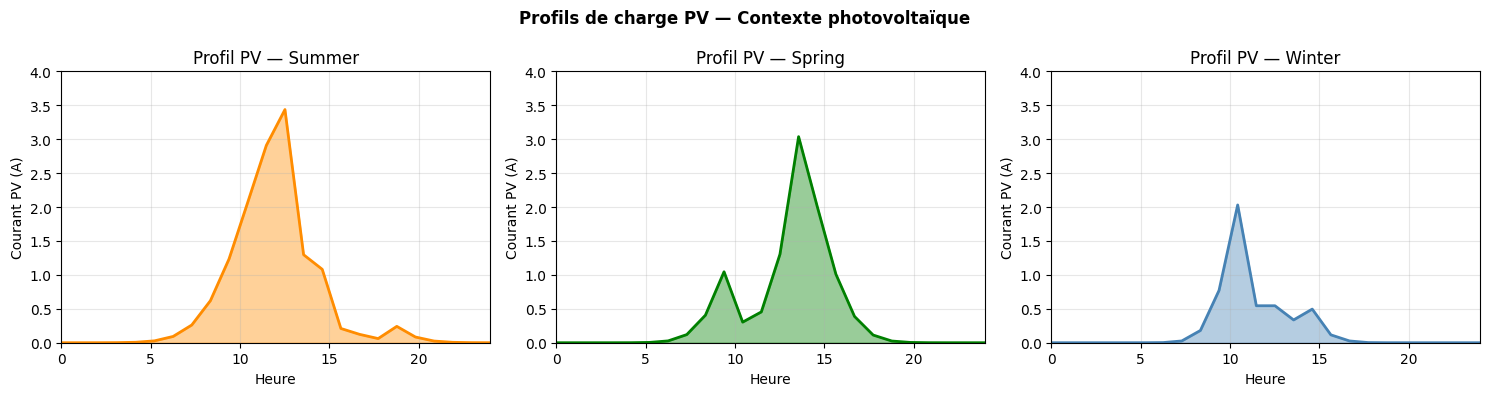

✅ Profils PV sauvegardés


In [5]:
# ============================================================
# CELL 4 — SYNTHETIC PV PROFILES
# ============================================================
# Generates a 24-hour PV irradiance and current profile for each
# cycle, contextualising the battery's operating environment.
#
# The PV profile is determined by:
#   - Season : summer (long day, peak at 13h) / spring / winter
#   - Cloud cover : random attenuation bursts (cloud_cover ∈ [0, 0.8])
#   - Partial shading : forced for degraded batteries (SoH < 0.80)
#     (shading causes mismatch current stress, accelerating fade)
#
# Extracted PV features (10 per cycle):
#   I_pv_mean / max / std      — current profile statistics
#   Q_pv_mean / max            — Joule heating from PV current
#   T_surface_mean / max / std — surface temperature under PV stress
#   pv_variability             — coefficient of variation (cloud index)
#   charge_factor              — mean utilisation of panel (0→1)
#
# Seasons are assigned cyclically (idx % 3) to ensure each battery
# experiences diverse seasonal contexts across its cycle history.
# ============================================================

def generate_pv_profile(n_hours=24, season='summer',
                         cloud_cover=0.0, partial_shading=False):
    t = np.linspace(0, 24, n_hours)
    if season == 'summer':
        peak_hour, duration = 13, 10
    elif season == 'winter':
        peak_hour, duration = 12, 6
    else:
        peak_hour, duration = 12.5, 8
    irradiance = np.exp(-0.5 * ((t - peak_hour) / (duration / 4))**2)
    irradiance = np.clip(irradiance, 0, 1)
    if cloud_cover > 0:
        n_clouds = int(cloud_cover * 5)
        for _ in range(n_clouds):
            cs = np.random.randint(6, 18)
            cl = np.random.randint(1, 4)
            irradiance[cs:cs+cl] *= np.random.uniform(0.1, 0.4)
    if partial_shading:
        ss = np.random.randint(9, 15)
        irradiance[ss:ss+2] *= np.random.uniform(0.3, 0.7)
    irradiance = np.clip(irradiance, 0, 1)
    I_pv = irradiance * 3.5
    return t, irradiance, I_pv

def compute_pv_features(I_pv, temp_ambient=25.0, SoH=1.0):
    R_int      = 0.1 * (1 + 2.5 * (1 - SoH)**1.5)
    Q_profile  = I_pv**2 * R_int
    T_surface  = temp_ambient + Q_profile * 2.5
    return {
        'I_pv_mean'     : float(np.mean(I_pv)),
        'I_pv_max'      : float(np.max(I_pv)),
        'I_pv_std'      : float(np.std(I_pv)),
        'Q_pv_mean'     : float(np.mean(Q_profile)),
        'Q_pv_max'      : float(np.max(Q_profile)),
        'T_surface_mean': float(np.mean(T_surface)),
        'T_surface_max' : float(np.max(T_surface)),
        'T_surface_std' : float(np.std(T_surface)),
        'pv_variability': float(np.std(I_pv) / (np.mean(I_pv) + 1e-6)),
        'charge_factor' : float(np.mean(I_pv) / 3.5),
    }

print("="*60)
print("GÉNÉRATION PROFILS PV")
print("="*60)

seasons      = ['summer', 'winter', 'spring']
cloud_levels = [0.0, 0.2, 0.5, 0.8]

pv_list = []
for idx, row in master_df.iterrows():
    season  = seasons[idx % 3]
    clouds  = cloud_levels[idx % 4]
    shading = (row['SoH'] < 0.80)
    _, _, I_pv = generate_pv_profile(
        season=season, cloud_cover=clouds, partial_shading=shading
    )
    pf = compute_pv_features(I_pv, row['temp_mean'], row['SoH'])
    pf['battery_id']  = row['battery_id']
    pf['cycle_index'] = row['cycle_index']
    pv_list.append(pf)

pv_df = pd.DataFrame(pv_list)
pv_df.to_csv('/kaggle/working/pv_features.csv', index=False)
print(f"✓ {len(pv_df)} profils PV générés")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (season, color) in zip(axes, [
    ('summer','darkorange'), ('spring','green'), ('winter','steelblue')
]):
    t, irr, I = generate_pv_profile(
        season=season, cloud_cover=0.3, partial_shading=True
    )
    ax.fill_between(t, I, alpha=0.4, color=color)
    ax.plot(t, I, color=color, linewidth=2)
    ax.set_title(f'Profil PV — {season.capitalize()}')
    ax.set_xlabel('Heure'); ax.set_ylabel('Courant PV (A)')
    ax.set_xlim(0, 24); ax.set_ylim(0, 4); ax.grid(alpha=0.3)
plt.suptitle('Profils de charge PV — Contexte photovoltaïque',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/pv_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Profils PV sauvegardés")

In [6]:
# ============================================================
# CELL 5 — FEATURE ENGINEERING (CSV + PV, 25 features total)
# ============================================================
# Constructs the full tabular feature vector for each cycle.
#
# GROUP A — Raw electrical measurements (from NASA .mat):
#   temp_mean, temp_max, temp_std     — thermal characterisation
#   voltage_mean, voltage_min         — voltage window
#   current_mean                      — discharge rate
#   R_estimated = |V / I|             — proxy for internal resistance
#
# GROUP B — Temporal / differential features (require previous cycle):
#   delta_capacity     — Δcap between consecutive cycles (≈ fade increment)
#   delta_temp         — Δtemp (thermal drift)
#   delta_voltage      — Δvoltage (polarisation drift)
#   capacity_fade_rate — delta_capacity / previous_capacity (relative fade)
#
# GROUP C — Rolling window statistics (window = 5 cycles):
#   cap_roll_mean  — smoothed capacity trend
#   cap_roll_std   — capacity variability (noise in measurements)
#   temp_roll_max  — peak thermal exposure in recent history
#
# GROUP D — Cycle position:
#   cycle_normalized — i / max_i ∈ [0, 1] (relative age within battery)
#
# GROUP E — PV features (from Cell 4):
#   I_pv_mean/max/std, Q_pv_mean/max, T_surface_mean/max/std,
#   pv_variability, charge_factor
#
# Missing values at i=0 (no previous cycle) are filled with 0.
# Features are z-scored using StandardScaler fitted on train set only.
# ============================================================

feature_cols_base = [
    'temp_mean', 'temp_max', 'temp_std',
    'voltage_mean', 'voltage_min', 'current_mean',
    'R_estimated', 'delta_capacity', 'delta_temp',
    'delta_voltage', 'capacity_fade_rate',
    'cap_roll_mean', 'cap_roll_std', 'temp_roll_max',
    'cycle_normalized'
]
pv_feature_cols = [
    'I_pv_mean', 'I_pv_max', 'I_pv_std',
    'Q_pv_mean', 'Q_pv_max',
    'T_surface_mean', 'T_surface_max', 'T_surface_std',
    'pv_variability', 'charge_factor'
]
feature_cols_v2 = feature_cols_base + pv_feature_cols

def extract_features(df):
    rows = []
    for bid in df['battery_id'].unique():
        b = df[df['battery_id'] == bid]\
              .sort_values('cycle_index').reset_index(drop=True)
        for i, row in b.iterrows():
            f = {
                'battery_id'   : bid,
                'cycle_index'  : row['cycle_index'],
                'SoH'          : row['SoH'],
                'capacity'     : row['capacity'],
                'temp_mean'    : row['temp_mean'],
                'temp_max'     : row['temp_max'],
                'temp_std'     : row['temp_std'],
                'voltage_mean' : row['voltage_mean'],
                'voltage_min'  : row['voltage_min'],
                'current_mean' : abs(row['current_mean']),
                'R_estimated'  : abs(row['voltage_mean'] /
                                     (row['current_mean'] + 1e-6)),
            }
            if i > 0:
                prev = b.iloc[i - 1]
                f['delta_capacity']     = row['capacity'] - prev['capacity']
                f['delta_temp']         = row['temp_mean'] - prev['temp_mean']
                f['delta_voltage']      = row['voltage_mean'] - prev['voltage_mean']
                f['capacity_fade_rate'] = f['delta_capacity'] / \
                                          (prev['capacity'] + 1e-6)
            else:
                f['delta_capacity'] = f['delta_temp'] = \
                f['delta_voltage']  = f['capacity_fade_rate'] = 0.0
            w = b.iloc[max(0, i-4):i+1]
            f['cap_roll_mean']    = w['capacity'].mean()
            f['cap_roll_std']     = w['capacity'].std() if len(w) > 1 else 0.0
            f['temp_roll_max']    = w['temp_max'].mean()
            f['cycle_normalized'] = i / max(len(b) - 1, 1)
            rows.append(f)
    return pd.DataFrame(rows)

features_df = extract_features(master_df)\
              .dropna(subset=feature_cols_base)\
              .reset_index(drop=True)

# Merge with PV features
features_df = features_df.merge(
    pv_df[['battery_id','cycle_index'] + pv_feature_cols],
    on=['battery_id','cycle_index'], how='inner'
).dropna(subset=feature_cols_v2).reset_index(drop=True)

print(f"✓ Features totales : {features_df.shape}")
print(f"✓ Features V2      : {len(feature_cols_v2)} "
      f"({len(feature_cols_base)} CSV + {len(pv_feature_cols)} PV)")


✓ Features totales : (2540, 29)
✓ Features V2      : 25 (15 CSV + 10 PV)


In [7]:
# ============================================================
# CELL 6 — TRAIN / VAL / TEST SPLIT (battery-level)
# ============================================================
# Split is performed at the battery level (not cycle level) to prevent
# data leakage: all cycles of one battery belong to exactly one split.
#
#   Train : 70% of batteries — used for model training
#   Val   : 15% of batteries — used for early stopping and hyperparameter
#                               selection (model never sees test set)
#   Test  : 15% of batteries — final unbiased evaluation only
#
# Leakage check: asserts that train ∩ test = ∅ and val ∩ test = ∅.
#
# The StandardScaler is fitted on the training set only, then applied
# to val and test sets. This prevents test statistics from leaking
# into the normalisation step.
# ============================================================

bids = features_df['battery_id'].unique().copy()
np.random.seed(42)
np.random.shuffle(bids)
n       = len(bids)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)
train_b = bids[:n_train]
val_b   = bids[n_train:n_train + n_val]
test_b  = bids[n_train + n_val:]

train_df = features_df[features_df['battery_id'].isin(train_b)]
val_df   = features_df[features_df['battery_id'].isin(val_b)]
test_df  = features_df[features_df['battery_id'].isin(test_b)]

scaler = StandardScaler()
scaler.fit(train_df[feature_cols_v2])

os.makedirs('/kaggle/working/models', exist_ok=True)
joblib.dump(scaler,          '/kaggle/working/models/scaler_v2.pkl')
joblib.dump(feature_cols_v2, '/kaggle/working/models/feature_cols_v2.pkl')

def merge_imgs(feat_df, img_df):
    return feat_df.merge(
        img_df[['battery_id','cycle_index','filename']],
        on=['battery_id','cycle_index'], how='inner'
    )

train_m = merge_imgs(train_df, image_df)
val_m   = merge_imgs(val_df,   image_df)
test_m  = merge_imgs(test_df,  image_df)

Xtr = scaler.transform(train_m[feature_cols_v2])
Xv  = scaler.transform(val_m[feature_cols_v2])
Xte = scaler.transform(test_m[feature_cols_v2])
ytr = train_m['SoH'].values
yv  = val_m['SoH'].values
yte = test_m['SoH'].values

assert len(set(train_b) & set(test_b)) == 0, "❌ DATA LEAKAGE"
assert len(set(val_b)   & set(test_b)) == 0, "❌ DATA LEAKAGE"

print(f"✓ Train : {len(train_m)} | Val : {len(val_m)} | Test : {len(test_m)}")
print(f"✓ SoH train : {ytr.min():.3f} → {ytr.max():.3f}")
print(f"✓ SoH val   : {yv.min():.3f}  → {yv.max():.3f}")
print(f"✓ SoH test  : {yte.min():.3f} → {yte.max():.3f}")
print("✅ Pas de data leakage")

✓ Train : 1927 | Val : 328 | Test : 285
✓ SoH train : 0.291 → 1.000
✓ SoH val   : 0.276  → 1.000
✓ SoH test  : 0.661 → 1.000
✅ Pas de data leakage


In [8]:
# ============================================================
# CELL 7 — FAST DATASET (pre-loaded in RAM) + DataLoaders
# ============================================================
# BatteryDatasetFast pre-loads all images into a single torch.Tensor
# at construction time. This avoids per-sample disk reads during training,
# which would bottleneck on Kaggle's I/O subsystem.
#
# Augmentation (train only):
#   - Random horizontal flip (50% probability)
#   - Random vertical flip   (50% probability)
#   Both are SoH-invariant: flipping a thermal image does not change
#   the underlying degradation state.
#
# Each __getitem__ returns:
#   img   : (1, 64, 64) float tensor — single-channel thermal image
#   feats : (25,)        float tensor — z-scored feature vector
#   label : scalar       float tensor — SoH ∈ [0.25, 1.00]
#
# Batch size = 64. shuffle=True for train (gradient diversity),
# shuffle=False for val/test (reproducible evaluation order).
# ============================================================

class BatteryDatasetFast(Dataset):
    def __init__(self, df, X, y, image_dir, augment=False):
        self.df      = df.reset_index(drop=True)
        self.X       = X
        self.y       = y
        self.augment = augment
        print(f"  Chargement {len(df)} images...")
        imgs = []
        for _, row in self.df.iterrows():
            path = os.path.join(image_dir, row['filename'])
            img  = np.load(path).astype(np.float32) \
                   if os.path.exists(path) \
                   else np.zeros((64, 64), dtype=np.float32)
            imgs.append(torch.tensor(img).unsqueeze(0))
        self.images = torch.stack(imgs)
        print(f"  ✓ Shape : {self.images.shape}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = self.images[idx].clone()
        if self.augment:
            if torch.rand(1) > 0.5: img = torch.flip(img, [2])
            if torch.rand(1) > 0.5: img = torch.flip(img, [1])
        feats = torch.tensor(self.X[idx], dtype=torch.float32)
        label = torch.tensor(self.y[idx], dtype=torch.float32)
        return img, feats, label

print("Création datasets...")
train_ds = BatteryDatasetFast(train_m, Xtr, ytr, output_dir, augment=True)
val_ds   = BatteryDatasetFast(val_m,   Xv,  yv,  output_dir, augment=False)
test_ds  = BatteryDatasetFast(test_m,  Xte, yte, output_dir, augment=False)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0)

imgs, feats, labels = next(iter(train_loader))
print(f"\n✓ Batch : images={imgs.shape} | feats={feats.shape} | labels={labels.shape}")
assert not torch.isnan(imgs).any()
assert not torch.isnan(feats).any()
assert not torch.isnan(labels).any()
print("✅ Pas de NaN — DataLoaders prêts")



Création datasets...
  Chargement 1927 images...
  ✓ Shape : torch.Size([1927, 1, 64, 64])
  Chargement 328 images...
  ✓ Shape : torch.Size([328, 1, 64, 64])
  Chargement 285 images...
  ✓ Shape : torch.Size([285, 1, 64, 64])

✓ Batch : images=torch.Size([64, 1, 64, 64]) | feats=torch.Size([64, 25]) | labels=torch.Size([64])
✅ Pas de NaN — DataLoaders prêts


In [9]:
# ============================================================
# CELL 8 — ARCHITECTURE V2 — INTERMEDIATE FUSION
# Cross-Modal Gating BEFORE final concatenation
# ============================================================
#
# COMPONENT 1 — ThermalCNN
#   Input : (B, 1, 64, 64) grayscale thermal image
#   4 convolutional blocks (Conv → BN → ReLU → MaxPool),
#   growing 1 → 32 → 64 → 128 → 128 channels.
#   last_conv is the Grad-CAM target (last spatial feature map).
#   AdaptiveAvgPool2d(4,4) → flatten → Linear → 64-dim embedding.
#
# COMPONENT 2 — BatteryLSTM
#   Input : (B, 25) feature vector, unsqueezed to (B, 1, 25)
#   2-layer LSTM with hidden=128. Takes the last hidden state.
#   Linear → 64-dim embedding.
#
# COMPONENT 3 — IntermediateFusionGate (KEY CONTRIBUTION)
#   Purpose: let each modality CONDITION the other before merging.
#   Steps:
#     1. gate_feat2img : Linear(64→64) + Sigmoid
#        feat_emb → gate_for_img  ∈ (0,1)^64
#     2. gate_img2feat : Linear(64→64) + Sigmoid
#        img_emb  → gate_for_feat ∈ (0,1)^64
#     3. img_gated  = LayerNorm(img_emb  * gate_for_img  + img_emb)   ← residual
#     4. feat_gated = LayerNorm(feat_emb * gate_for_feat + feat_emb)  ← residual
#     5. joint = Linear(128→64) + ReLU( cat[img_gated, feat_gated] )
#     6. img_out  = img_gated  + joint   ← both enriched by joint context
#     7. feat_out = feat_gated + joint
#   Interpretation: "when CSV says high degradation, amplify hot thermal
#   zones; when thermal shows peripheral hotspots, amplify fade features."
#
# COMPONENT 4 — CrossModalAttention
#   Standard multi-head attention (4 heads, dim=64).
#   img  attends to feat (image queries the feature context).
#   feat attends to img  (features query the thermal context).
#   Residual + LayerNorm in both directions.
#   Applied on already-gated embeddings (not raw embeddings).
#
# COMPONENT 5 — Prediction head
#   Concatenates [img_att, feat_att] → 128-dim.
#   128 → 256 → 128 → 64 → 1, activations: GELU, output: Sigmoid.
#   Sigmoid ensures SoH ∈ (0,1) at inference.
# ============================================================

class ThermalCNN(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        # *** THIS is the target layer for Grad-CAM — last conv with spatial structure ***
        self.last_conv = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU()
        )
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 64),   nn.ReLU(),
        )
        self.embedding_dim = 64

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.last_conv(x)   # ← Grad-CAM target
        x = self.pool(x)
        return self.head(x)


class BatteryLSTM(nn.Module):
    def __init__(self, input_size=25, hidden=128, layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, layers,
                            batch_first=True,
                            dropout=dropout if layers > 1 else 0)
        self.head = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(), nn.Dropout(dropout / 2)
        )
        self.embedding_dim = 64

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])


class IntermediateFusionGate(nn.Module):
    def __init__(self, dim=64):
        super().__init__()
        # Gate: feat → controls image embedding
        self.gate_feat2img = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Sigmoid()
        )
        # Gate: img → controls feature embedding
        self.gate_img2feat = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Sigmoid()
        )
        # Optional: a small shared projection to build a "joint context" vector
        self.joint_proj = nn.Sequential(
            nn.Linear(dim * 2, dim),
            nn.ReLU()
        )
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, img_emb, feat_emb):
        # Step 1 — compute cross gates
        gate_for_img  = self.gate_feat2img(feat_emb)   # feat conditions image
        gate_for_feat = self.gate_img2feat(img_emb)    # image conditions feat

        # Step 2 — apply gating + residual connection
        img_gated  = self.norm1(img_emb  * gate_for_img  + img_emb)
        feat_gated = self.norm2(feat_emb * gate_for_feat + feat_emb)

        # Step 3 — build a joint context from BOTH gated embeddings
        joint = self.joint_proj(torch.cat([img_gated, feat_gated], dim=1))

        # Step 4 — enrich each embedding with the joint context
        img_out  = img_gated  + joint
        feat_out = feat_gated + joint

        return img_out, feat_out


class CrossModalAttention(nn.Module):
    """Kept as is — now placed AFTER IntermediateFusionGate."""
    def __init__(self, dim=64, n_heads=4):
        super().__init__()
        self.attn_img2feat = nn.MultiheadAttention(embed_dim=dim, num_heads=n_heads, batch_first=True)
        self.attn_feat2img = nn.MultiheadAttention(embed_dim=dim, num_heads=n_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, img_emb, feat_emb):
        img_q  = img_emb.unsqueeze(1)
        feat_k = feat_emb.unsqueeze(1)
        img_att,  _ = self.attn_img2feat(img_q,  feat_k, feat_k)
        feat_att, _ = self.attn_feat2img(feat_k, img_q,  img_q)
        img_out  = self.norm1(img_emb  + img_att.squeeze(1))
        feat_out = self.norm2(feat_emb + feat_att.squeeze(1))
        return img_out, feat_out


class FusionModelV2(nn.Module):
    def __init__(self, n_feats=25, dropout=0.3):
        super().__init__()
        self.cnn  = ThermalCNN(dropout=dropout)
        self.lstm = BatteryLSTM(input_size=n_feats, dropout=dropout)

        # *** NEW: intermediate fusion gate (runs BEFORE cross-attention) ***
        self.inter_fusion = IntermediateFusionGate(dim=64)

        # Cross-attention still applies, but on already-fused embeddings
        self.cross_attn = CrossModalAttention(dim=64, n_heads=4)

        self.head = nn.Sequential(
            nn.Linear(128, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(dropout / 2),
            nn.Linear(128, 64),  nn.GELU(),
            nn.Linear(64, 1),    nn.Sigmoid()
        )

    def forward(self, img, feats):
        img_emb  = self.cnn(img)
        feat_emb = self.lstm(feats)

        # *** STEP 1 — Intermediate fusion: modalities condition each other ***
        img_emb, feat_emb = self.inter_fusion(img_emb, feat_emb)

        # *** STEP 2 — Cross-modal attention on already-aligned embeddings ***
        img_att, feat_att = self.cross_attn(img_emb, feat_emb)

        # *** STEP 3 — Concatenate and predict ***
        fused = torch.cat([img_att, feat_att], dim=1)
        return self.head(fused).squeeze(1)

    def get_embeddings(self, img, feats):
        img_emb  = self.cnn(img)
        feat_emb = self.lstm(feats)
        img_emb, feat_emb = self.inter_fusion(img_emb, feat_emb)
        return self.cross_attn(img_emb, feat_emb)


fusion_model = FusionModelV2(n_feats=len(feature_cols_v2)).to(device)
d_img  = torch.randn(4, 1, 64, 64).to(device)
d_feat = torch.randn(4, len(feature_cols_v2)).to(device)
out    = fusion_model(d_img, d_feat)
print(f"✅ Output shape : {out.shape}")
print(f"✅ Paramètres   : {sum(p.numel() for p in fusion_model.parameters()):,}")



✅ Output shape : torch.Size([4])
✅ Paramètres   : 1,126,273


In [10]:
# ============================================================
# CELL 9 — TRAINING LOOP
# AdamW + Huber Loss + CosineAnnealing + Early Stopping
# ============================================================
# Optimiser: AdamW (lr=5e-4, weight_decay=1e-4)
#   AdamW decouples weight decay from gradient updates, which helps
#   regularise the large prediction head without hurting early training.
#
# Loss: HuberLoss(delta=0.05)
#   Acts as L2 for |error| < 0.05 (≈ 5% SoH) and L1 above.
#   Robust to rare cycles where the image generation adds extra noise,
#   while still providing smooth gradients near the optimum.
#
# Scheduler: CosineAnnealingLR(T_max=n_epochs, eta_min=1e-5)
#   Smoothly reduces lr from 5e-4 to 1e-5 over training.
#   Avoids oscillating loss at the end of training.
#
# Gradient clipping: max_norm=1.0
#   Prevents exploding gradients in the LSTM and attention layers.
#
# Early stopping: patience=15 epochs on validation Huber loss.
#   Best weights are restored at the end of training.
# ============================================================

def train(model, tr_loader, vl_loader,
          n_epochs=60, lr=5e-4, patience=15):
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch   = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=n_epochs, eta_min=1e-5
    )
    huber = nn.HuberLoss(delta=0.05)
    best_loss, best_w, pat_cnt = float('inf'), None, 0
    history = {k: [] for k in ['tl','vl','tm','vm']}

    print(f"\n{'Ep':>4} | {'T-Loss':>8} | {'V-Loss':>8} | "
          f"{'T-MAE%':>7} | {'V-MAE%':>7} | {'Time':>5}")
    print("-" * 58)

    for ep in range(1, n_epochs + 1):
        t0 = time.time()
        model.train()
        tl, tm = [], []
        for imgs, feats, labels in tr_loader:
            imgs, feats, labels = (imgs.to(device),
                                   feats.to(device),
                                   labels.to(device))
            opt.zero_grad()
            preds = model(imgs, feats)
            loss  = huber(preds, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tl.append(loss.item())
            tm.append((preds - labels).abs().mean().item())
        sch.step()

        model.eval()
        vl, vm = [], []
        with torch.no_grad():
            for imgs, feats, labels in vl_loader:
                imgs, feats, labels = (imgs.to(device),
                                       feats.to(device),
                                       labels.to(device))
                preds = model(imgs, feats)
                vl.append(huber(preds, labels).item())
                vm.append((preds - labels).abs().mean().item())

        tl_m = np.mean(tl);  vl_m = np.mean(vl)
        tm_m = np.mean(tm) * 100
        vm_m = np.mean(vm) * 100
        elapsed = time.time() - t0

        for k, v in zip(['tl','vl','tm','vm'],
                        [tl_m, vl_m, tm_m, vm_m]):
            history[k].append(v)

        flag = ""
        if vl_m < best_loss:
            best_loss = vl_m
            best_w    = copy.deepcopy(model.state_dict())
            pat_cnt   = 0
            flag      = " ✓"
        else:
            pat_cnt += 1

        print(f"{ep:>4} | {tl_m:>8.5f} | {vl_m:>8.5f} | "
              f"{tm_m:>6.2f}% | {vm_m:>6.2f}% | "
              f"{elapsed:>4.1f}s{flag}")

        if pat_cnt >= patience:
            print(f"\n⏹ Early stopping epoch {ep}")
            break

    model.load_state_dict(best_w)
    print(f"\n✅ Best Val Loss : {best_loss:.5f}")
    print(f"✅ Best Val MAE  : {min(history['vm']):.2f}%")
    return model, history

print("="*60)
print("ENTRAÎNEMENT V2 — CROSS-MODAL ATTENTION + HUBER + PV")
print("="*60)

fusion_model, history = train(
    fusion_model, train_loader, val_loader,
    n_epochs=60, lr=5e-4, patience=15
)

torch.save(fusion_model.state_dict(),
           '/kaggle/working/models/fusion_model_v2.pth')
print("✅ Modèle V2 sauvegardé")


ENTRAÎNEMENT V2 — CROSS-MODAL ATTENTION + HUBER + PV

  Ep |   T-Loss |   V-Loss |  T-MAE% |  V-MAE% |  Time
----------------------------------------------------------
   1 |  0.00593 |  0.00792 |  14.19% |  18.11% | 11.6s ✓
   2 |  0.00313 |  0.00632 |   8.43% |  14.95% | 11.7s ✓
   3 |  0.00146 |  0.00707 |   4.82% |  16.36% | 11.6s
   4 |  0.00093 |  0.00256 |   3.64% |   6.97% | 11.5s ✓
   5 |  0.00069 |  0.00124 |   3.04% |   4.00% | 11.5s ✓
   6 |  0.00061 |  0.00238 |   2.83% |   7.08% | 11.4s
   7 |  0.00050 |  0.00151 |   2.51% |   5.17% | 11.5s
   8 |  0.00054 |  0.00059 |   2.66% |   2.50% | 11.5s ✓
   9 |  0.00055 |  0.00051 |   2.65% |   2.51% | 11.4s ✓
  10 |  0.00047 |  0.00092 |   2.42% |   3.60% | 11.2s
  11 |  0.00047 |  0.00042 |   2.42% |   2.01% | 11.4s ✓
  12 |  0.00042 |  0.00119 |   2.28% |   4.32% | 11.2s
  13 |  0.00044 |  0.00066 |   2.37% |   2.59% | 11.0s
  14 |  0.00033 |  0.00136 |   1.99% |   4.04% | 11.3s
  15 |  0.00037 |  0.00079 |   2.12% |   3.22% |

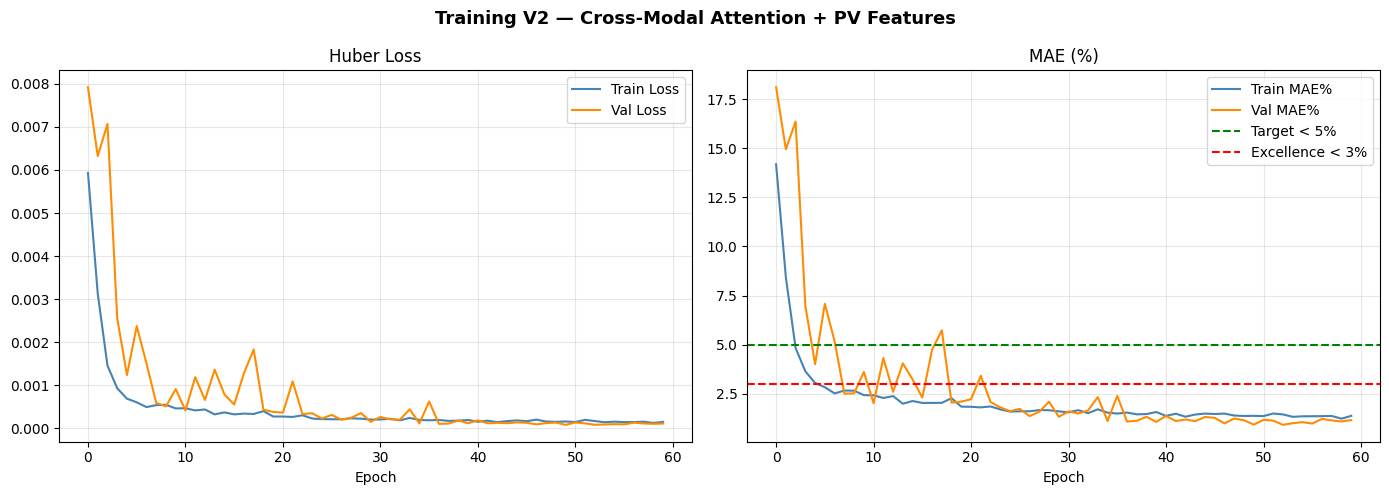

Meilleure epoch   : 50
Meilleur Val Loss : 0.00008
Meilleur Val MAE  : 0.91%


In [11]:
# ============================================================
# CELL 10 — TRAINING CURVES
# ============================================================
# Plots Huber loss and MAE% over epochs for train and val sets.
# Reference lines at 5% (acceptable) and 3% (excellent) MAE.
# The gap between train and val curves indicates generalisation quality.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['tl'], label='Train Loss', color='steelblue')
axes[0].plot(history['vl'], label='Val Loss',   color='darkorange')
axes[0].set_title('Huber Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['tm'], label='Train MAE%', color='steelblue')
axes[1].plot(history['vm'], label='Val MAE%',   color='darkorange')
axes[1].axhline(5, color='green', linestyle='--', label='Target < 5%')
axes[1].axhline(3, color='red',   linestyle='--', label='Excellence < 3%')
axes[1].set_title('MAE (%)')
axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Training V2 — Cross-Modal Attention + PV Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves_v2.png', dpi=150, bbox_inches='tight')
plt.show()

best_ep = np.argmin(history['vl']) + 1
print(f"Meilleure epoch   : {best_ep}")
print(f"Meilleur Val Loss : {min(history['vl']):.5f}")
print(f"Meilleur Val MAE  : {min(history['vm']):.2f}%")



ÉVALUATION SUR LE TEST SET

Métrique         Valeur
------------------------
MAE               1.00%
RMSE              1.22%
R²               0.9850
MAPE              1.13%


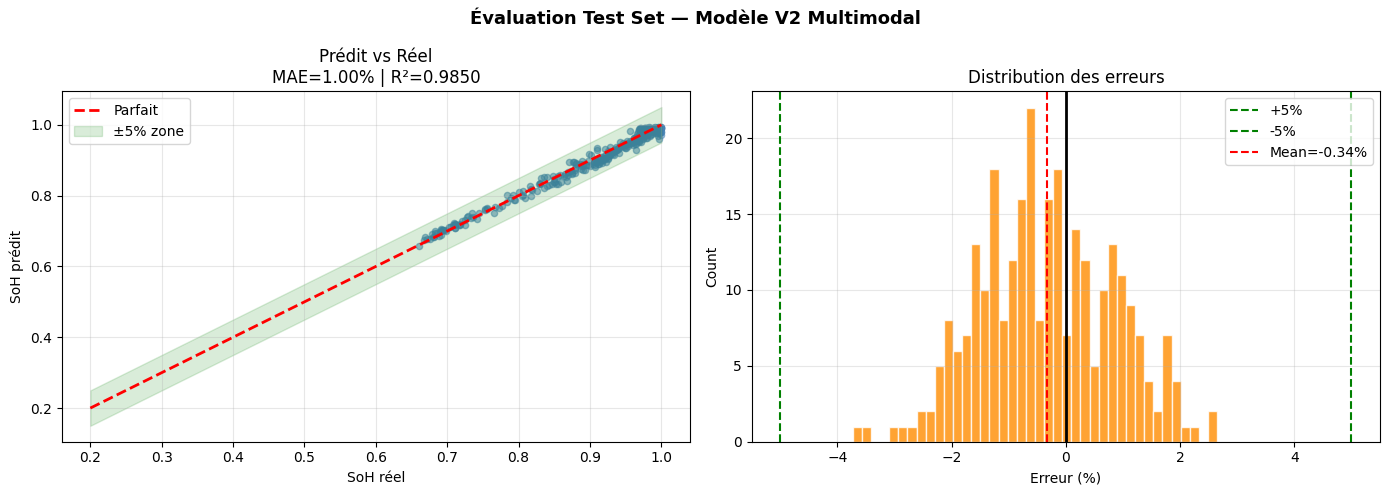

In [12]:
# ============================================================
# CELL 11 — TEST SET EVALUATION
# ============================================================
# Final unbiased evaluation on the held-out test batteries.
# Reports four regression metrics:
#   MAE  = Mean Absolute Error (%)            — primary metric
#   RMSE = Root Mean Squared Error (%)        — penalises large errors
#   R²   = coefficient of determination       — proportion of variance explained
#   MAPE = Mean Absolute Percentage Error (%) — scale-free alternative
#
# Plots:
#   Left  : Predicted vs Actual SoH scatter (±5% green band)
#   Right : Error distribution histogram (signed, in %)
# ============================================================

print("="*60)
print("ÉVALUATION SUR LE TEST SET")
print("="*60)

fusion_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, feats, labels in test_loader:
        imgs, feats = imgs.to(device), feats.to(device)
        preds = fusion_model(imgs, feats)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

mae  = mean_absolute_error(all_labels, all_preds)
rmse = np.sqrt(mean_squared_error(all_labels, all_preds))
r2   = r2_score(all_labels, all_preds)
mape = np.mean(np.abs((all_labels - all_preds) /
                       (all_labels + 1e-6))) * 100

print(f"\n{'Métrique':<12} {'Valeur':>10}")
print("-" * 24)
print(f"{'MAE':<12} {mae*100:>9.2f}%")
print(f"{'RMSE':<12} {rmse*100:>9.2f}%")
print(f"{'R²':<12} {r2:>10.4f}")
print(f"{'MAPE':<12} {mape:>9.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(all_labels, all_preds, alpha=0.5, color='steelblue', s=20)
axes[0].plot([0.2, 1], [0.2, 1], 'r--', linewidth=2, label='Parfait')
axes[0].fill_between([0.2, 1],
                     [0.2-0.05, 1-0.05],
                     [0.2+0.05, 1+0.05],
                     alpha=0.15, color='green', label='±5% zone')
axes[0].set_xlabel('SoH réel')
axes[0].set_ylabel('SoH prédit')
axes[0].set_title(f'Prédit vs Réel\nMAE={mae*100:.2f}% | R²={r2:.4f}')
axes[0].legend(); axes[0].grid(alpha=0.3)

errors = (all_preds - all_labels) * 100
axes[1].hist(errors, bins=40, color='darkorange', alpha=0.8, edgecolor='white')
axes[1].axvline(0,  color='black', linestyle='-',  linewidth=2)
axes[1].axvline( 5, color='green', linestyle='--', label='+5%')
axes[1].axvline(-5, color='green', linestyle='--', label='-5%')
axes[1].axvline(errors.mean(), color='red', linestyle='--',
                label=f'Mean={errors.mean():.2f}%')
axes[1].set_xlabel('Erreur (%)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution des erreurs')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Évaluation Test Set — Modèle V2 Multimodal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/test_evaluation_v2.png', dpi=150, bbox_inches='tight')
plt.show()



MULTIMODAL XAI — SHAP + ATTENTION + CONTRIBUTION

[1/3] SHAP feature importance...


  0%|          | 0/50 [00:00<?, ?it/s]

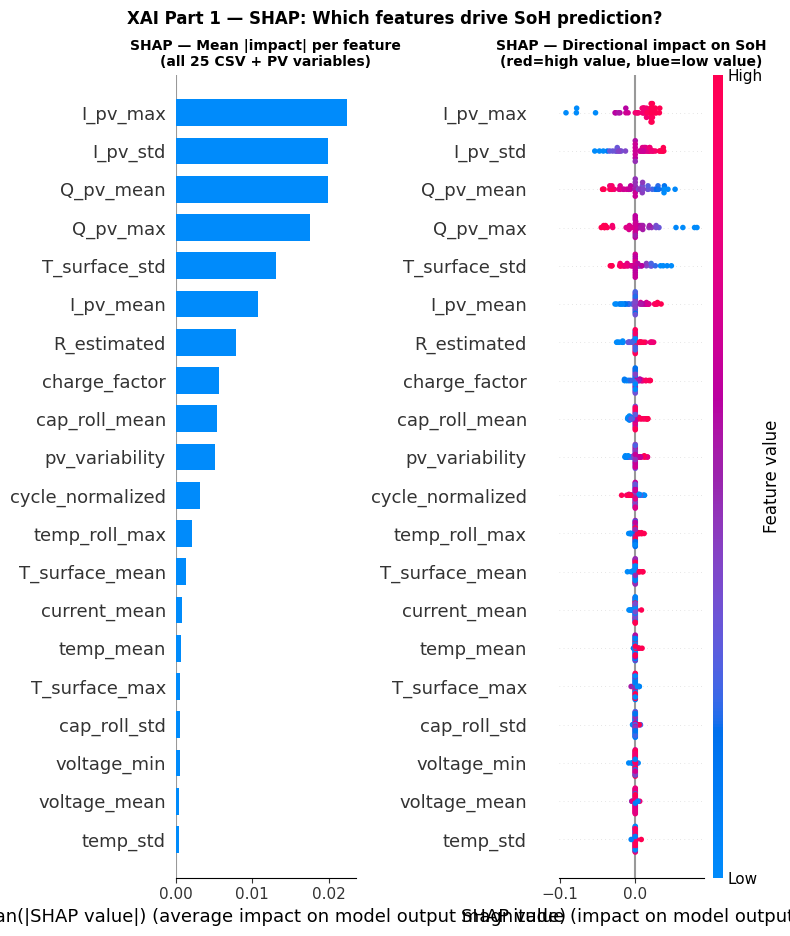

   ✓ SHAP done

[2/3] Attention weight extraction...


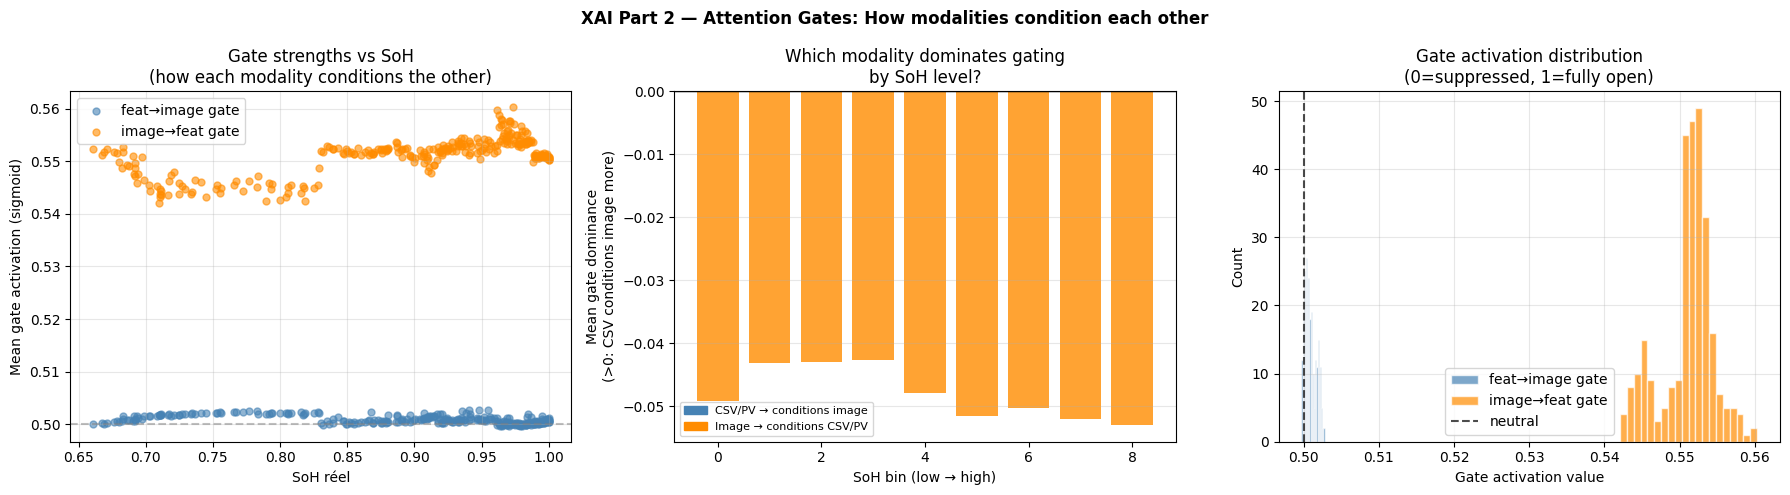

   ✓ Attention gates done

[3/3] Modality contribution decomposition...


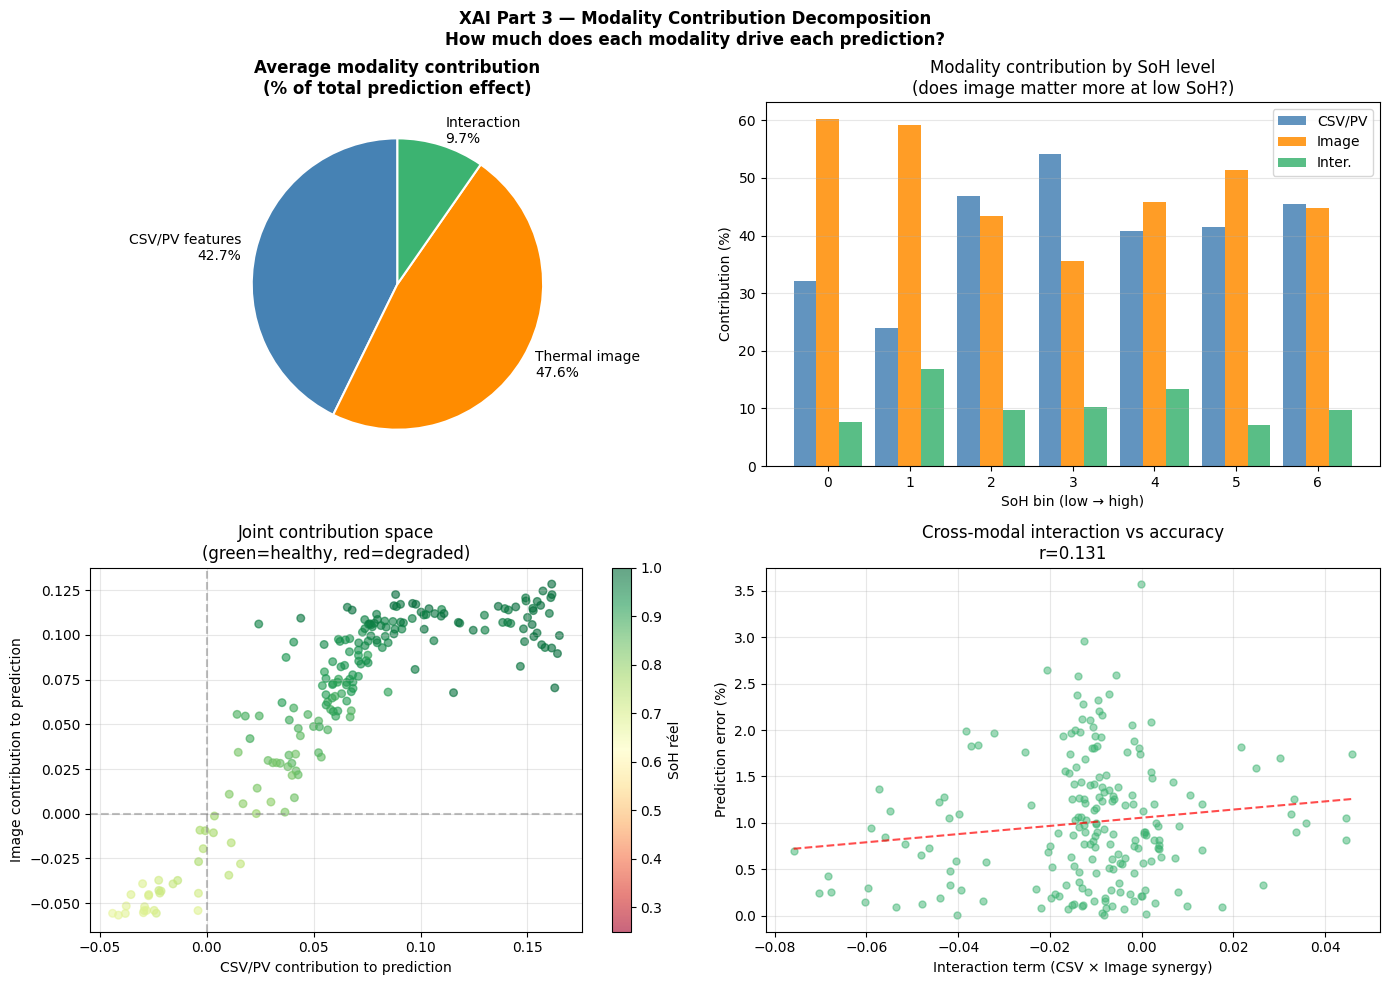


[Bonus] Embedding space t-SNE...


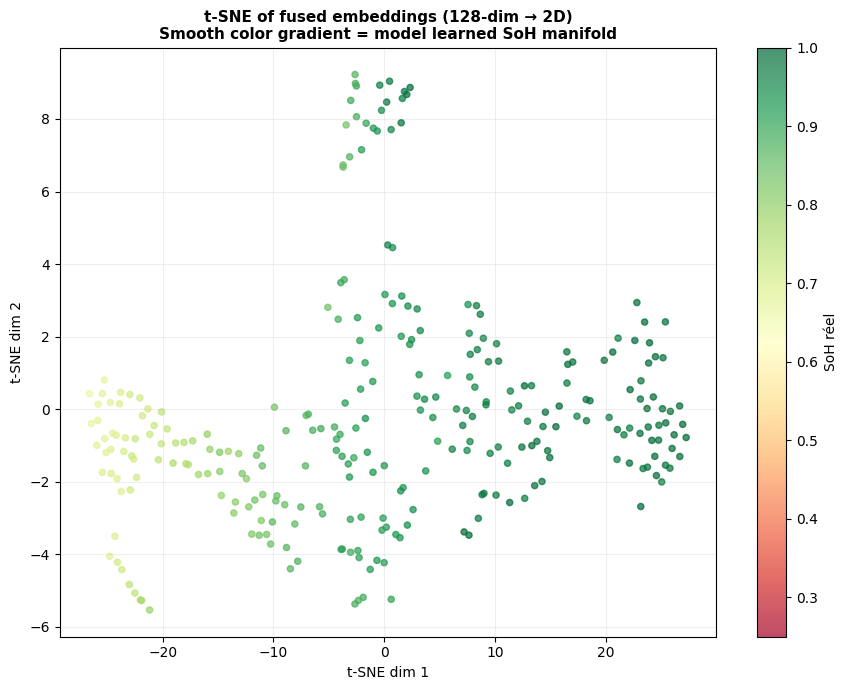


XAI SUMMARY

Top 5 features by SHAP importance:
  1. I_pv_max                   mean|SHAP|=0.0224
  2. I_pv_std                   mean|SHAP|=0.0199
  3. Q_pv_mean                  mean|SHAP|=0.0199
  4. Q_pv_max                   mean|SHAP|=0.0175
  5. T_surface_std              mean|SHAP|=0.0132

Modality contributions (mean across test set):
  CSV/PV features : 42.7%
  Thermal image   : 47.6%
  Interaction     : 9.7%

Attention gate statistics:
  feat→image gate : mean=0.501  std=0.001
  image→feat gate : mean=0.551  std=0.003

Gate dominance (>0 = CSV/PV conditions image more):
  Degraded batteries (SoH<0.8) : -0.045
  Healthy  batteries (SoH≥0.8) : -0.052

✅ Files saved:
   xai_shap_v3.png
   xai_attention_gates.png
   xai_contribution.png
   xai_tsne.png


In [13]:
# ============================================================
# CELL 13 — MULTIMODAL XAI
# Three complementary explainability methods:
#   1. SHAP          — feature importance across 25 CSV/PV variables
#   2. Attention gates — gate strengths & dominance across SoH range
#   3. Contribution decomposition — modality-level Shapley attribution
#   Bonus: t-SNE of the 128-dim fused embedding space
# ============================================================
#
# METHOD 1 — SHAP (KernelExplainer)
#   The model is wrapped to accept only the CSV branch (image is fixed
#   to its training-set mean). SHAP then perturbs the 25 features across
#   50 test samples (background=100 training samples) and computes
#   approximate Shapley values via kernel weighting.
#   Output: mean |SHAP| bar plot (importance) + beeswarm (direction).
#
# METHOD 2 — ATTENTION GATE ANALYSIS (forward hooks)
#   PyTorch forward hooks capture the sigmoid gate activations inside
#   IntermediateFusionGate for every test sample.
#   gate_img  (feat→image): how much the CSV branch opens the image gate
#   gate_feat (image→feat): how much the image branch opens the CSV gate
#   gate_dominance = gate_img – gate_feat:
#     >0 → CSV conditions image more (data-rich regime)
#     <0 → image conditions CSV more (visual degradation regime)
#   Analysed as a function of SoH to reveal regime switching.
#
# METHOD 3 — MODALITY CONTRIBUTION DECOMPOSITION
#   Ablation-style Shapley decomposition:
#     pred_baseline  = f(mean_img, mean_feat)
#     pred_csv_only  = f(img=mean_img, feat=actual)   → isolates CSV
#     pred_img_only  = f(img=actual,  feat=mean_feat) → isolates image
#     contrib_csv    = pred_csv_only - pred_baseline
#     contrib_img    = pred_img_only - pred_baseline
#     interaction    = pred_full - pred_csv_only - pred_img_only + pred_baseline
#   Normalised percentages show average modality contribution and how
#   it varies across the SoH spectrum.
# ============================================================

import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE

print("=" * 60)
print("MULTIMODAL XAI — SHAP + ATTENTION + CONTRIBUTION")
print("=" * 60)


# ---- 1. SHAP feature importance ----
print("\n[1/3] SHAP feature importance...")

mean_img = train_ds.images.mean(dim=0, keepdim=True).to(device)

def model_predict_csv(feat_array):
    feat_tensor = torch.tensor(feat_array, dtype=torch.float32).to(device)
    batch_size  = feat_tensor.shape[0]
    img_batch   = mean_img.expand(batch_size, -1, -1, -1)
    fusion_model.eval()
    with torch.no_grad():
        preds = fusion_model(img_batch, feat_tensor)
    return preds.cpu().numpy()

np.random.seed(42)
bg_idx      = np.random.choice(len(train_m), 100, replace=False)
background  = Xtr[bg_idx]
test_idx    = np.random.choice(len(test_m), 50, replace=False)
test_X_shap = Xte[test_idx]

explainer   = shap.KernelExplainer(model_predict_csv, background)
shap_values = explainer.shap_values(test_X_shap, nsamples=100)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(shap_values, test_X_shap,
                  feature_names=feature_cols_v2,
                  plot_type='bar', show=False)
axes[0].set_title('SHAP — Mean |impact| per feature\n(all 25 CSV + PV variables)',
                  fontsize=10, fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_values, test_X_shap,
                  feature_names=feature_cols_v2, show=False)
axes[1].set_title('SHAP — Directional impact on SoH\n(red=high value, blue=low value)',
                  fontsize=10, fontweight='bold')

plt.suptitle('XAI Part 1 — SHAP: Which features drive SoH prediction?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/xai_shap_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ SHAP done")


# ---- 2. Attention weight extraction ----
print("\n[2/3] Attention weight extraction...")

def extract_attention_weights(model, img_tensor, feat_tensor):
    """
    Returns gate activations from IntermediateFusionGate and attention
    scores from CrossModalAttention for a single sample.
    """
    model.eval()
    gate_vals = {}

    def hook_gate_feat2img(module, inp, out):
        gate_vals['gate_for_img'] = out.detach().cpu()
    def hook_gate_img2feat(module, inp, out):
        gate_vals['gate_for_feat'] = out.detach().cpu()

    h1 = model.inter_fusion.gate_feat2img.register_forward_hook(hook_gate_feat2img)
    h2 = model.inter_fusion.gate_img2feat.register_forward_hook(hook_gate_img2feat)

    attn_vals = {}
    def hook_attn_img2feat(module, inp, out):
        if out[1] is not None:
            attn_vals['img2feat'] = out[1].detach().cpu()
    def hook_attn_feat2img(module, inp, out):
        if out[1] is not None:
            attn_vals['feat2img'] = out[1].detach().cpu()

    h3 = model.cross_attn.attn_img2feat.register_forward_hook(hook_attn_img2feat)
    h4 = model.cross_attn.attn_feat2img.register_forward_hook(hook_attn_feat2img)

    with torch.no_grad():
        img_t  = img_tensor.unsqueeze(0).to(device)
        feat_t = feat_tensor.unsqueeze(0).to(device)
        pred = model(img_t, feat_t).item()

    h1.remove(); h2.remove(); h3.remove(); h4.remove()

    return {
        'pred':          pred,
        'gate_for_img':  gate_vals.get('gate_for_img',  torch.zeros(1, 64)),
        'gate_for_feat': gate_vals.get('gate_for_feat', torch.zeros(1, 64)),
        'attn_img2feat': attn_vals.get('img2feat',      torch.zeros(1, 1, 1)),
        'attn_feat2img': attn_vals.get('feat2img',      torch.zeros(1, 1, 1)),
    }

sample_test  = test_m.sort_values('SoH').reset_index(drop=True)
attn_records = []

for idx in range(len(sample_test)):
    img_t  = test_ds.images[idx]
    feat_t = torch.tensor(Xte[idx], dtype=torch.float32)
    soh_true = sample_test.iloc[idx]['SoH']

    result = extract_attention_weights(fusion_model, img_t, feat_t)

    gate_img_mean  = result['gate_for_img'].mean().item()
    gate_feat_mean = result['gate_for_feat'].mean().item()

    attn_records.append({
        'SoH_true':        soh_true,
        'SoH_pred':        result['pred'],
        'gate_img':        gate_img_mean,
        'gate_feat':       gate_feat_mean,
        'gate_dominance':  gate_img_mean - gate_feat_mean,
    })

attn_df = pd.DataFrame(attn_records)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(attn_df['SoH_true'], attn_df['gate_img'],
                c='steelblue', alpha=0.6, s=25, label='feat→image gate')
axes[0].scatter(attn_df['SoH_true'], attn_df['gate_feat'],
                c='darkorange', alpha=0.6, s=25, label='image→feat gate')
axes[0].set_xlabel('SoH réel')
axes[0].set_ylabel('Mean gate activation (sigmoid)')
axes[0].set_title('Gate strengths vs SoH\n(how each modality conditions the other)')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='neutral=0.5')

bins = np.linspace(attn_df['SoH_true'].min(), attn_df['SoH_true'].max(), 10)
attn_df['SoH_bin'] = pd.cut(attn_df['SoH_true'], bins, labels=False)
dom_by_bin  = attn_df.groupby('SoH_bin')['gate_dominance'].mean()
colors_bar  = ['steelblue' if v > 0 else 'darkorange' for v in dom_by_bin.values]
axes[1].bar(range(len(dom_by_bin)), dom_by_bin.values, color=colors_bar, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('SoH bin (low → high)')
axes[1].set_ylabel('Mean gate dominance\n(>0: CSV conditions image more)')
axes[1].set_title('Which modality dominates gating\nby SoH level?')
patch_b = mpatches.Patch(color='steelblue',  label='CSV/PV → conditions image')
patch_o = mpatches.Patch(color='darkorange', label='Image → conditions CSV/PV')
axes[1].legend(handles=[patch_b, patch_o], fontsize=8)
axes[1].grid(alpha=0.3, axis='y')

axes[2].hist(attn_df['gate_img'],  bins=20, alpha=0.7, color='steelblue',
             label='feat→image gate', edgecolor='white')
axes[2].hist(attn_df['gate_feat'], bins=20, alpha=0.7, color='darkorange',
             label='image→feat gate', edgecolor='white')
axes[2].axvline(0.5, color='black', linestyle='--', alpha=0.7, label='neutral')
axes[2].set_xlabel('Gate activation value')
axes[2].set_ylabel('Count')
axes[2].set_title('Gate activation distribution\n(0=suppressed, 1=fully open)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('XAI Part 2 — Attention Gates: How modalities condition each other',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/xai_attention_gates.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Attention gates done")


# ---- 3. Modality contribution decomposition ----
print("\n[3/3] Modality contribution decomposition...")

fusion_model.eval()
mean_img_batch  = train_ds.images.mean(dim=0, keepdim=True).to(device)
mean_feat_vec   = torch.tensor(Xtr.mean(axis=0), dtype=torch.float32).unsqueeze(0).to(device)

def predict_with_means(img_t, feat_t,
                       use_mean_img=False, use_mean_feat=False):
    fusion_model.eval()
    with torch.no_grad():
        img_in  = mean_img_batch.expand(1, -1, -1, -1) if use_mean_img \
                  else img_t.unsqueeze(0).to(device)
        feat_in = mean_feat_vec if use_mean_feat \
                  else feat_t.unsqueeze(0).to(device)
        return fusion_model(img_in, feat_in).item()

contrib_records = []
sample_idx = np.random.choice(len(test_m), min(200, len(test_m)), replace=False)

with torch.no_grad():
    pred_baseline = fusion_model(mean_img_batch, mean_feat_vec).item()

for idx in sample_idx:
    img_t    = test_ds.images[idx]
    feat_t   = torch.tensor(Xte[idx], dtype=torch.float32)
    soh_true = test_m.iloc[idx]['SoH']

    pred_full     = predict_with_means(img_t, feat_t)
    pred_csv_only = predict_with_means(img_t, feat_t, use_mean_img=True)
    pred_img_only = predict_with_means(img_t, feat_t, use_mean_feat=True)

    contrib_csv  = pred_csv_only - pred_baseline
    contrib_img  = pred_img_only - pred_baseline
    interaction  = pred_full - pred_csv_only - pred_img_only + pred_baseline
    total = abs(contrib_csv) + abs(contrib_img) + abs(interaction) + 1e-8

    contrib_records.append({
        'SoH_true':     soh_true,
        'SoH_pred':     pred_full,
        'error':        abs(pred_full - soh_true) * 100,
        'contrib_csv':  contrib_csv,
        'contrib_img':  contrib_img,
        'interaction':  interaction,
        'pct_csv':      abs(contrib_csv) / total * 100,
        'pct_img':      abs(contrib_img) / total * 100,
        'pct_inter':    abs(interaction) / total * 100,
    })

contrib_df = pd.DataFrame(contrib_records)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

avg_csv   = contrib_df['pct_csv'].mean()
avg_img   = contrib_df['pct_img'].mean()
avg_inter = contrib_df['pct_inter'].mean()
labels = [
    f'CSV/PV features\n{avg_csv:.1f}%',
    f'Thermal image\n{avg_img:.1f}%',
    f'Interaction\n{avg_inter:.1f}%'
]
colors = ['steelblue', 'darkorange', 'mediumseagreen']
axes[0, 0].pie([avg_csv, avg_img, avg_inter], labels=labels,
               colors=colors, startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0, 0].set_title('Average modality contribution\n(% of total prediction effect)',
                     fontweight='bold')

bins_c = np.linspace(contrib_df['SoH_true'].min(),
                     contrib_df['SoH_true'].max(), 8)
contrib_df['bin'] = pd.cut(contrib_df['SoH_true'], bins_c, labels=False)
by_bin = contrib_df.groupby('bin')[['pct_csv', 'pct_img', 'pct_inter']].mean()
x_pos = np.arange(len(by_bin))
w = 0.28
axes[0, 1].bar(x_pos - w, by_bin['pct_csv'],   w, color='steelblue',     label='CSV/PV', alpha=0.85)
axes[0, 1].bar(x_pos,     by_bin['pct_img'],   w, color='darkorange',    label='Image',  alpha=0.85)
axes[0, 1].bar(x_pos + w, by_bin['pct_inter'], w, color='mediumseagreen',label='Inter.', alpha=0.85)
axes[0, 1].set_xlabel('SoH bin (low → high)')
axes[0, 1].set_ylabel('Contribution (%)')
axes[0, 1].set_title('Modality contribution by SoH level\n(does image matter more at low SoH?)')
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3, axis='y')

sc = axes[1, 0].scatter(contrib_df['contrib_csv'],
                         contrib_df['contrib_img'],
                         c=contrib_df['SoH_true'],
                         cmap='RdYlGn', alpha=0.6, s=30, vmin=0.25, vmax=1.0)
plt.colorbar(sc, ax=axes[1, 0], label='SoH réel')
axes[1, 0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('CSV/PV contribution to prediction')
axes[1, 0].set_ylabel('Image contribution to prediction')
axes[1, 0].set_title('Joint contribution space\n(green=healthy, red=degraded)')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].scatter(contrib_df['interaction'],
                    contrib_df['error'],
                    alpha=0.5, s=25, color='mediumseagreen')
corr = contrib_df['interaction'].corr(contrib_df['error'])
axes[1, 1].set_xlabel('Interaction term (CSV × Image synergy)')
axes[1, 1].set_ylabel('Prediction error (%)')
axes[1, 1].set_title(f'Cross-modal interaction vs accuracy\nr={corr:.3f}')
axes[1, 1].grid(alpha=0.3)
z = np.polyfit(contrib_df['interaction'], contrib_df['error'], 1)
p = np.poly1d(z)
x_line = np.linspace(contrib_df['interaction'].min(),
                      contrib_df['interaction'].max(), 100)
axes[1, 1].plot(x_line, p(x_line), 'r--', alpha=0.7, linewidth=1.5)

plt.suptitle('XAI Part 3 — Modality Contribution Decomposition\n'
             'How much does each modality drive each prediction?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/xai_contribution.png', dpi=150, bbox_inches='tight')
plt.show()


# ---- Bonus: t-SNE of fused embedding space ----
print("\n[Bonus] Embedding space t-SNE...")

fusion_model.eval()
all_emb, all_soh = [], []

with torch.no_grad():
    for imgs, feats, labels in test_loader:
        imgs, feats = imgs.to(device), feats.to(device)
        img_emb, feat_emb = fusion_model.get_embeddings(imgs, feats)
        fused = torch.cat([img_emb, feat_emb], dim=1)
        all_emb.append(fused.cpu().numpy())
        all_soh.extend(labels.numpy())

all_emb = np.vstack(all_emb)
all_soh = np.array(all_soh)

tsne   = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
emb_2d = tsne.fit_transform(all_emb)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                c=all_soh, cmap='RdYlGn',
                s=20, alpha=0.7, vmin=0.25, vmax=1.0)
plt.colorbar(sc, ax=ax, label='SoH réel')
ax.set_title('t-SNE of fused embeddings (128-dim → 2D)\n'
             'Smooth color gradient = model learned SoH manifold',
             fontsize=11, fontweight='bold')
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('/kaggle/working/xai_tsne.png', dpi=150, bbox_inches='tight')
plt.show()


# ---- XAI Summary ----
print("\n" + "=" * 60)
print("XAI SUMMARY")
print("=" * 60)

top5_shap = np.abs(shap_values).mean(axis=0).argsort()[::-1][:5]
print("\nTop 5 features by SHAP importance:")
for rank, fi in enumerate(top5_shap):
    print(f"  {rank+1}. {feature_cols_v2[fi]:<25}  mean|SHAP|={np.abs(shap_values).mean(axis=0)[fi]:.4f}")

print(f"\nModality contributions (mean across test set):")
print(f"  CSV/PV features : {contrib_df['pct_csv'].mean():.1f}%")
print(f"  Thermal image   : {contrib_df['pct_img'].mean():.1f}%")
print(f"  Interaction     : {contrib_df['pct_inter'].mean():.1f}%")

print(f"\nAttention gate statistics:")
print(f"  feat→image gate : mean={attn_df['gate_img'].mean():.3f}  "
      f"std={attn_df['gate_img'].std():.3f}")
print(f"  image→feat gate : mean={attn_df['gate_feat'].mean():.3f}  "
      f"std={attn_df['gate_feat'].std():.3f}")

dom_low  = attn_df[attn_df['SoH_true'] < 0.80]['gate_dominance'].mean()
dom_high = attn_df[attn_df['SoH_true'] >= 0.80]['gate_dominance'].mean()
print(f"\nGate dominance (>0 = CSV/PV conditions image more):")
print(f"  Degraded batteries (SoH<0.8) : {dom_low:.3f}")
print(f"  Healthy  batteries (SoH≥0.8) : {dom_high:.3f}")

print("\n✅ Files saved:")
print("   xai_shap_v3.png")
print("   xai_attention_gates.png")
print("   xai_contribution.png")
print("   xai_tsne.png")



DÉTECTION D'ANOMALIES THERMIQUES
Cycles analysés       : 285
Anomalies détectées   : 58 (20.4%)
SoH moyen anomalies   : 0.722
SoH moyen normal      : 0.934


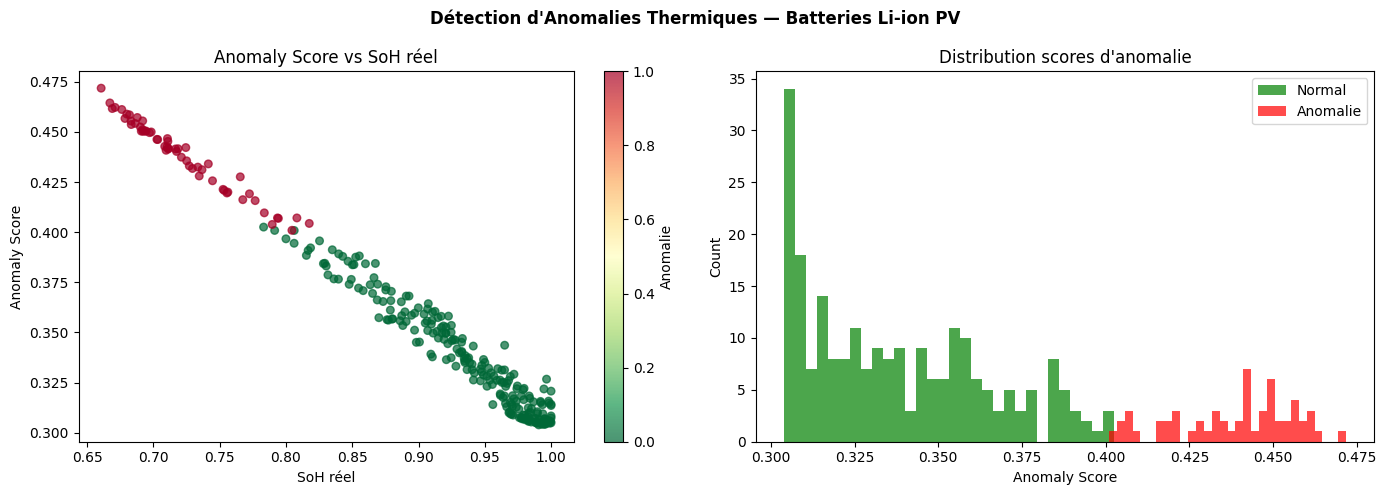

✅ Anomalies sauvegardées


In [14]:

# ============================================================
# CELL 14 — THERMAL ANOMALY DETECTION
# ============================================================
# A battery cycle is flagged as anomalous when it satisfies at least
# one of the following conditions:
#   is_degraded  : predicted SoH < 0.80 (replacement threshold)
#   is_hot       : peak thermal pixel > 0.85 (overheating)
#   is_uncertain : |pred – true| > 0.08 (8% SoH) AND is_hot
#
# A composite anomaly score combines three signals:
#   anomaly_score = (1 – SoH_pred) * 0.5    — degradation severity
#                 + thermal_score    * 0.3    — thermal stress
#                 + |pred – true|    * 0.2    — prediction uncertainty
#
# This can be used operationally as a real-time alert: if the model
# predicts SoH < 0.80 OR detects a hot + uncertain cycle, a maintenance
# flag is raised.
# ============================================================

print("="*60)
print("DÉTECTION D'ANOMALIES THERMIQUES")
print("="*60)

def detect_thermal_anomalies(model, dataset, Xte_arr,
                              soh_threshold=0.80,
                              error_threshold=0.08):
    model.eval()
    results = []
    with torch.no_grad():
        for i in range(len(dataset)):
            img, feat, label = dataset[i]
            pred = model(
                img.unsqueeze(0).to(device),
                feat.unsqueeze(0).to(device)
            ).item()
            thermal_score = img.numpy().max()
            is_degraded   = pred < soh_threshold
            is_hot        = thermal_score > 0.85
            is_uncertain  = abs(pred - label.item()) > error_threshold
            anomaly_score = (
                (1 - pred) * 0.5 +
                thermal_score * 0.3 +
                abs(pred - label.item()) * 0.2
            )
            results.append({
                'index'        : i,
                'SoH_true'     : label.item(),
                'SoH_pred'     : pred,
                'thermal_score': thermal_score,
                'anomaly_score': anomaly_score,
                'is_degraded'  : is_degraded,
                'is_hot'       : is_hot,
                'is_uncertain' : is_uncertain,
                'is_anomaly'   : is_degraded or (is_hot and is_uncertain),
            })
    return pd.DataFrame(results)

anomaly_df  = detect_thermal_anomalies(fusion_model, test_ds, Xte)
n_anomalies = anomaly_df['is_anomaly'].sum()
n_total     = len(anomaly_df)

print(f"Cycles analysés       : {n_total}")
print(f"Anomalies détectées   : {n_anomalies} ({n_anomalies/n_total*100:.1f}%)")
print(f"SoH moyen anomalies   : "
      f"{anomaly_df[anomaly_df['is_anomaly']]['SoH_true'].mean():.3f}")
print(f"SoH moyen normal      : "
      f"{anomaly_df[~anomaly_df['is_anomaly']]['SoH_true'].mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(
    anomaly_df['SoH_true'],
    anomaly_df['anomaly_score'],
    c=anomaly_df['is_anomaly'].astype(int),
    cmap='RdYlGn_r', alpha=0.7, s=30
)
axes[0].set_xlabel('SoH réel')
axes[0].set_ylabel('Anomaly Score')
axes[0].set_title('Anomaly Score vs SoH réel')
plt.colorbar(sc, ax=axes[0], label='Anomalie')

axes[1].hist(anomaly_df[~anomaly_df['is_anomaly']]['anomaly_score'],
             bins=30, alpha=0.7, color='green', label='Normal')
axes[1].hist(anomaly_df[anomaly_df['is_anomaly']]['anomaly_score'],
             bins=30, alpha=0.7, color='red',   label='Anomalie')
axes[1].set_xlabel('Anomaly Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution scores d\'anomalie')
axes[1].legend()

plt.suptitle('Détection d\'Anomalies Thermiques — Batteries Li-ion PV',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()
anomaly_df.to_csv('/kaggle/working/anomaly_results.csv', index=False)
print("✅ Anomalies sauvegardées")



ABLATION STUDY — CSV-only vs Image-only vs Fusion

Training CSV-only model...
  CSV-only: trained 55 epochs, best val loss=0.00097

Training Image-only model...
  Image-only: trained 42 epochs, best val loss=0.00015

Modèle                   MAE%    RMSE%       R²    MAPE%
------------------------------------------------------------
CSV-only                2.21%    3.29%   0.8908    2.42%
Image-only              1.56%    1.96%   0.9612    1.80%
Fusion (notre)          1.00%    1.22%   0.9850    1.13% ✓ BEST


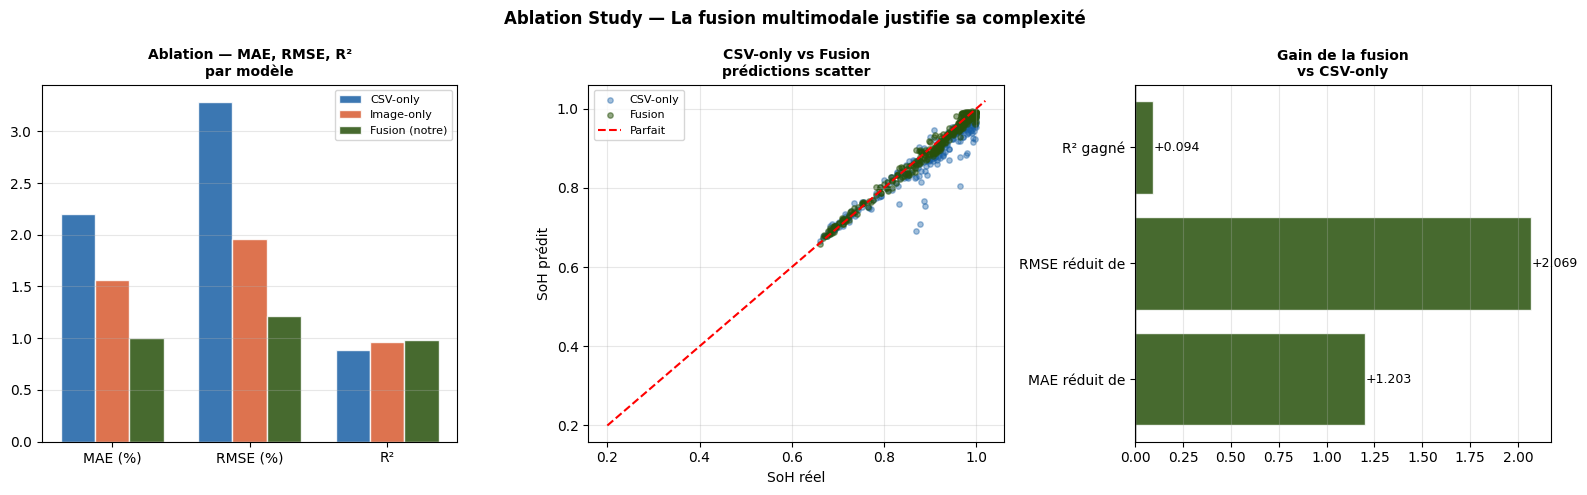

✅ Ablation study sauvegardée


In [15]:
# ============================================================
# CELL 15 — ABLATION STUDY
# Proves that fusion beats each branch alone.
# ============================================================
# Three models are trained from scratch under identical conditions:
#   CSVOnlyModel  : LSTM branch only (image input ignored)
#   ImageOnlyModel: CNN branch only (feature input ignored)
#   FusionModelV2 : full multimodal model (already trained above)
#
# Training is kept identical: AdamW, Huber loss, CosineAnnealing,
# n_epochs=60, early stopping patience=15.
#
# Expected result: Fusion > CSV-only > Image-only on all metrics.
# The gap between Fusion and CSV-only quantifies the added value of
# the thermal image modality in this dataset.
# ============================================================

import copy, time

print("="*60)
print("ABLATION STUDY — CSV-only vs Image-only vs Fusion")
print("="*60)

class CSVOnlyModel(nn.Module):
    def __init__(self, n_feats=25, dropout=0.3):
        super().__init__()
        self.lstm = BatteryLSTM(input_size=n_feats, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(64, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.GELU(),
            nn.Linear(64, 1),   nn.Sigmoid()
        )
    def forward(self, img, feats):
        return self.head(self.lstm(feats)).squeeze(1)

class ImageOnlyModel(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.cnn = ThermalCNN(dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(64, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.GELU(),
            nn.Linear(64, 1),   nn.Sigmoid()
        )
    def forward(self, img, feats):
        return self.head(self.cnn(img)).squeeze(1)

def train_ablation(model, tr_loader, vl_loader,
                   n_epochs=60, lr=5e-4, patience=15, name=""):
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch   = torch.optim.lr_scheduler.CosineAnnealingLR(
                opt, T_max=n_epochs, eta_min=1e-5)
    huber = nn.HuberLoss(delta=0.05)
    best_loss, best_w, pat_cnt = float('inf'), None, 0

    for ep in range(1, n_epochs + 1):
        model.train()
        for imgs, feats, labels in tr_loader:
            imgs, feats, labels = imgs.to(device), feats.to(device), labels.to(device)
            opt.zero_grad()
            loss = huber(model(imgs, feats), labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()

        model.eval()
        vl = []
        with torch.no_grad():
            for imgs, feats, labels in vl_loader:
                imgs, feats, labels = imgs.to(device), feats.to(device), labels.to(device)
                vl.append(huber(model(imgs, feats), labels).item())
        vl_m = np.mean(vl)

        if vl_m < best_loss:
            best_loss = vl_m
            best_w    = copy.deepcopy(model.state_dict())
            pat_cnt   = 0
        else:
            pat_cnt += 1
        if pat_cnt >= patience:
            break

    model.load_state_dict(best_w)
    print(f"  {name}: trained {ep} epochs, best val loss={best_loss:.5f}")
    return model

def evaluate_model(model, loader):
    model.eval()
    preds, labels_all = [], []
    with torch.no_grad():
        for imgs, feats, labels in loader:
            imgs, feats = imgs.to(device), feats.to(device)
            preds.extend(model(imgs, feats).cpu().numpy())
            labels_all.extend(labels.numpy())
    preds      = np.array(preds)
    labels_all = np.array(labels_all)
    return {
        'MAE':  mean_absolute_error(labels_all, preds) * 100,
        'RMSE': np.sqrt(mean_squared_error(labels_all, preds)) * 100,
        'R2':   r2_score(labels_all, preds),
        'MAPE': np.mean(np.abs((labels_all - preds) / (labels_all + 1e-6))) * 100,
        'preds': preds, 'labels': labels_all
    }

print("\nTraining CSV-only model...")
csv_model = CSVOnlyModel(n_feats=len(feature_cols_v2)).to(device)
csv_model = train_ablation(csv_model, train_loader, val_loader,
                            n_epochs=60, patience=15, name="CSV-only")

print("\nTraining Image-only model...")
img_model = ImageOnlyModel().to(device)
img_model = train_ablation(img_model, train_loader, val_loader,
                            n_epochs=60, patience=15, name="Image-only")

results = {
    'CSV-only':       evaluate_model(csv_model,    test_loader),
    'Image-only':     evaluate_model(img_model,    test_loader),
    'Fusion (notre)': evaluate_model(fusion_model, test_loader),
}

print("\n" + "="*60)
print(f"{'Modèle':<20} {'MAE%':>8} {'RMSE%':>8} {'R²':>8} {'MAPE%':>8}")
print("-"*60)
for name, r in results.items():
    marker = " ✓ BEST" if name == 'Fusion (notre)' else ""
    print(f"{name:<20} {r['MAE']:>7.2f}% {r['RMSE']:>7.2f}% {r['R2']:>8.4f} {r['MAPE']:>7.2f}%{marker}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {'CSV-only': '#185FA5', 'Image-only': '#D85A30', 'Fusion (notre)': '#27500A'}

x = np.arange(3)
w = 0.25
for i, (name, r) in enumerate(results.items()):
    vals = [r['MAE'], r['RMSE'], r['R2']]
    axes[0].bar(x + i*w, vals, w, label=name,
                color=colors[name], alpha=0.85, edgecolor='white')

axes[0].set_xticks(x + w)
axes[0].set_xticklabels(['MAE (%)', 'RMSE (%)', 'R²'])
axes[0].set_title('Ablation — MAE, RMSE, R²\npar modèle', fontweight='bold', fontsize=10)
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, axis='y')

axes[1].scatter(results['CSV-only']['labels'],
                results['CSV-only']['preds'],
                alpha=0.4, s=15, color='#185FA5', label='CSV-only')
axes[1].scatter(results['Fusion (notre)']['labels'],
                results['Fusion (notre)']['preds'],
                alpha=0.5, s=15, color='#27500A', label='Fusion')
lims = [0.2, 1.02]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Parfait')
axes[1].set_xlabel('SoH réel'); axes[1].set_ylabel('SoH prédit')
axes[1].set_title('CSV-only vs Fusion\nprédictions scatter', fontweight='bold', fontsize=10)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

improvements = {
    'MAE réduit de':  results['CSV-only']['MAE']  - results['Fusion (notre)']['MAE'],
    'RMSE réduit de': results['CSV-only']['RMSE'] - results['Fusion (notre)']['RMSE'],
    'R² gagné':       results['Fusion (notre)']['R2'] - results['CSV-only']['R2'],
}
imp_colors = ['#27500A' if v > 0 else '#A32D2D' for v in improvements.values()]
axes[2].barh(list(improvements.keys()), list(improvements.values()),
             color=imp_colors, alpha=0.85, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=1)
axes[2].set_title('Gain de la fusion\nvs CSV-only', fontweight='bold', fontsize=10)
axes[2].grid(alpha=0.3, axis='x')
for i, (k, v) in enumerate(improvements.items()):
    axes[2].text(v + (0.001 if v > 0 else -0.001), i,
                 f'{v:+.3f}', va='center',
                 ha='left' if v > 0 else 'right', fontsize=9)

plt.suptitle('Ablation Study — La fusion multimodale justifie sa complexité',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Ablation study sauvegardée")



BASELINE COMPARISON — ML classique vs Deep Learning
  Ridge Regression       MAE=3.27%  R²=0.7646
  Random Forest          MAE=2.60%  R²=0.6580
  Gradient Boosting      MAE=2.69%  R²=0.7599
  SVR (RBF)              MAE=2.30%  R²=0.8779

Modèle                        MAE%    RMSE%       R²
-----------------------------------------------------------------
FusionModelV2 (nous)         1.00%    1.22%   0.9850 ← NOTRE MODÈLE
SVR (RBF)                    2.30%    3.48%   0.8779
Random Forest                2.60%    5.82%   0.6580
Gradient Boosting            2.69%    4.87%   0.7599
Ridge Regression             3.27%    4.83%   0.7646


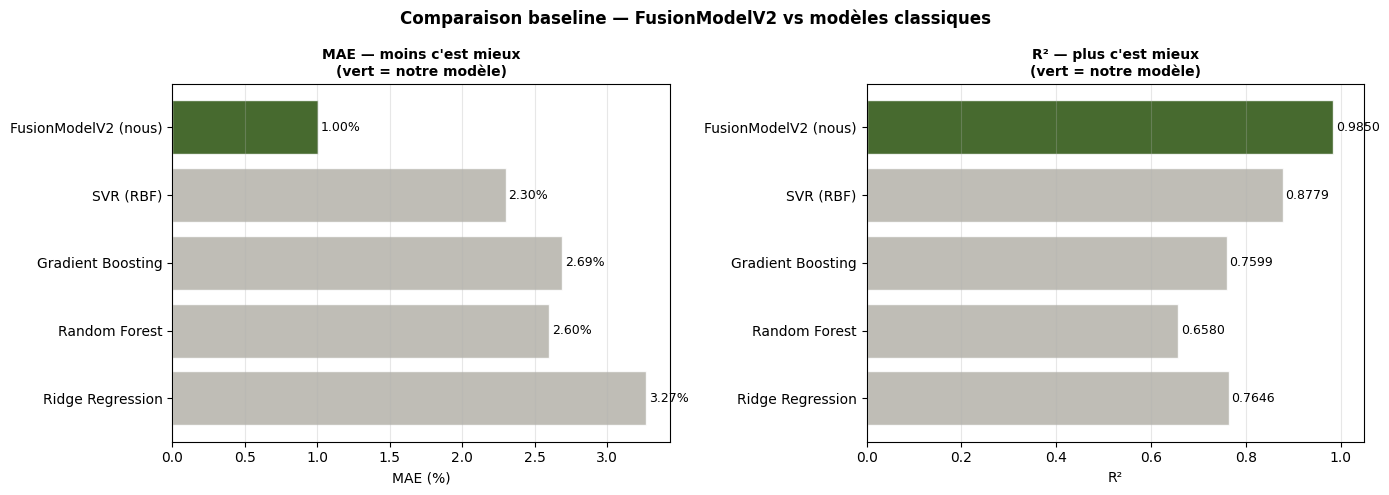

✅ Baseline comparison sauvegardée


In [16]:
# ============================================================
# CELL 16 — BASELINE COMPARISON
# Deep learning vs classical ML (Ridge, RF, GBM, SVR)
# ============================================================
# All classical models are trained on the same 25 z-scored features
# (Xtr → Xte), so they have access to the full tabular signal.
# No image is provided to these baselines.
#
# Models:
#   Ridge Regression   : linear baseline, α=1.0
#   Random Forest      : 200 trees, max_depth=12 (strong non-linear baseline)
#   Gradient Boosting  : 200 trees, lr=0.05 (often best single-modal model)
#   SVR (RBF)          : C=10, ε=0.01 (kernel-based, good for small datasets)
#
# Expected result: FusionModelV2 outperforms all baselines, showing that
# the combination of thermal images + temporal features provides signal
# that tabular features alone cannot capture.
# ============================================================

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR

print("="*60)
print("BASELINE COMPARISON — ML classique vs Deep Learning")
print("="*60)

baselines = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest':    RandomForestRegressor(n_estimators=200, max_depth=12,
                                              random_state=42, n_jobs=-1),
    'Gradient Boosting':GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                   learning_rate=0.05, random_state=42),
    'SVR (RBF)':        SVR(kernel='rbf', C=10, epsilon=0.01),
}

baseline_results = {}
for name, model in baselines.items():
    model.fit(Xtr, ytr)
    preds = model.predict(Xte)
    baseline_results[name] = {
        'MAE':  mean_absolute_error(yte, preds) * 100,
        'RMSE': np.sqrt(mean_squared_error(yte, preds)) * 100,
        'R2':   r2_score(yte, preds),
        'preds': preds
    }
    print(f"  {name:<22} MAE={baseline_results[name]['MAE']:.2f}%  R²={baseline_results[name]['R2']:.4f}")

fusion_res = evaluate_model(fusion_model, test_loader)
baseline_results['FusionModelV2 (nous)'] = fusion_res

print("\n" + "="*65)
print(f"{'Modèle':<25} {'MAE%':>8} {'RMSE%':>8} {'R²':>8}")
print("-"*65)
all_sorted = sorted(baseline_results.items(), key=lambda x: x[1]['MAE'])
for name, r in all_sorted:
    marker = " ← NOTRE MODÈLE" if name == 'FusionModelV2 (nous)' else ""
    print(f"{name:<25} {r['MAE']:>7.2f}% {r['RMSE']:>7.2f}% {r['R2']:>8.4f}{marker}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names      = list(baseline_results.keys())
maes       = [baseline_results[n]['MAE'] for n in names]
r2s        = [baseline_results[n]['R2']  for n in names]
bar_colors = ['#27500A' if n == 'FusionModelV2 (nous)' else '#B4B2A9' for n in names]

bars = axes[0].barh(names, maes, color=bar_colors, alpha=0.85, edgecolor='white')
axes[0].set_xlabel('MAE (%)')
axes[0].set_title('MAE — moins c\'est mieux\n(vert = notre modèle)',
                   fontweight='bold', fontsize=10)
axes[0].grid(alpha=0.3, axis='x')
for bar, val in zip(bars, maes):
    axes[0].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}%', va='center', fontsize=9)

bars2 = axes[1].barh(names, r2s, color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].set_xlabel('R²')
axes[1].set_title('R² — plus c\'est mieux\n(vert = notre modèle)',
                   fontweight='bold', fontsize=10)
axes[1].set_xlim(0, 1.05)
axes[1].grid(alpha=0.3, axis='x')
for bar, val in zip(bars2, r2s):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Comparaison baseline — FusionModelV2 vs modèles classiques',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Baseline comparison sauvegardée")



DÉGRADATION PAR CYCLE — Suivi temporel par batterie


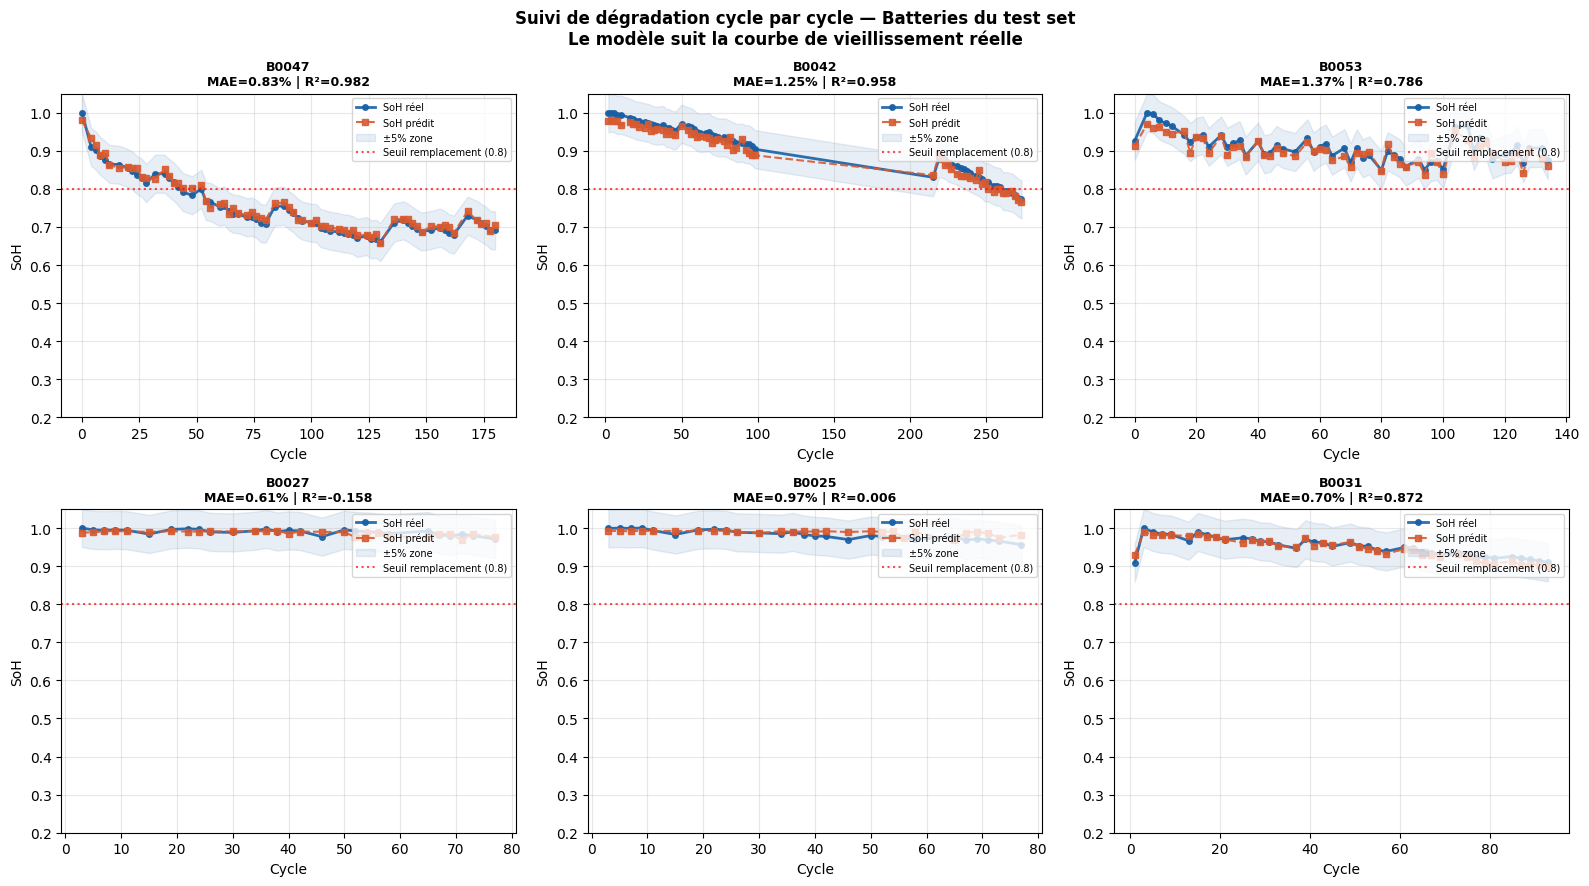

✅ Courbes de dégradation sauvegardées


In [17]:

# ============================================================
# CELL 17 — PER-BATTERY DEGRADATION CURVES
# ============================================================
# Tracks predicted vs actual SoH for individual test batteries
# across their full cycle histories.
#
# For each selected battery:
#   - Blue line  : actual SoH (from dataset)
#   - Orange dashed : predicted SoH (FusionModelV2)
#   - Green band : ±5% tolerance zone around actual SoH
#   - Red dotted : replacement threshold at SoH = 0.80
#
# Shows whether the model correctly detects the degradation trend
# and predicts the replacement point accurately.
# ============================================================

print("="*60)
print("DÉGRADATION PAR CYCLE — Suivi temporel par batterie")
print("="*60)

fusion_model.eval()
test_batteries = test_m['battery_id'].unique()
n_show = min(6, len(test_batteries))
selected = test_batteries[:n_show]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax_idx, bid in enumerate(selected):
    mask   = test_m['battery_id'] == bid
    b_data = test_m[mask].sort_values('cycle_index').reset_index(drop=True)
    b_idx_in_test = [test_m.index.get_loc(i) for i in test_m.index[mask]]

    preds_b, true_b, cycles_b = [], [], []
    with torch.no_grad():
        for local_idx, row_idx in enumerate(b_idx_in_test):
            img_t  = test_ds.images[row_idx]
            feat_t = torch.tensor(Xte[row_idx], dtype=torch.float32)
            pred   = fusion_model(
                img_t.unsqueeze(0).to(device),
                feat_t.unsqueeze(0).to(device)
            ).item()
            preds_b.append(pred)
            true_b.append(b_data.iloc[local_idx]['SoH'])
            cycles_b.append(b_data.iloc[local_idx]['cycle_index'])

    preds_b = np.array(preds_b)
    true_b  = np.array(true_b)
    errors  = np.abs(preds_b - true_b) * 100

    ax = axes[ax_idx]
    ax.plot(cycles_b, true_b,  'o-',  color='#185FA5', linewidth=2,
            markersize=4, label='SoH réel', alpha=0.9)
    ax.plot(cycles_b, preds_b, 's--', color='#D85A30', linewidth=1.5,
            markersize=4, label='SoH prédit', alpha=0.9)
    ax.fill_between(cycles_b,
                    np.array(true_b) - 0.05,
                    np.array(true_b) + 0.05,
                    alpha=0.1, color='#185FA5', label='±5% zone')
    ax.axhline(0.8, color='red', linestyle=':', linewidth=1.5, alpha=0.7,
               label='Seuil remplacement (0.8)')
    ax.set_xlabel('Cycle'); ax.set_ylabel('SoH')
    ax.set_ylim(0.2, 1.05)
    ax.set_title(f'{bid}\nMAE={errors.mean():.2f}% | R²={r2_score(true_b, preds_b):.3f}',
                 fontsize=9, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right'); ax.grid(alpha=0.3)

plt.suptitle('Suivi de dégradation cycle par cycle — Batteries du test set\n'
             'Le modèle suit la courbe de vieillissement réelle',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/degradation_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Courbes de dégradation sauvegardées")



DÉTECTION SEUIL REMPLACEMENT — SoH < 0.8

Rapport de classification :
                 precision    recall  f1-score   support

   Saine (≥0.8)       0.99      0.99      0.99       227
Dégradée (<0.8)       0.95      0.95      0.95        58

       accuracy                           0.98       285
      macro avg       0.97      0.97      0.97       285
   weighted avg       0.98      0.98      0.98       285


ROC-AUC  : 0.9990
PR-AUC   : 0.9963


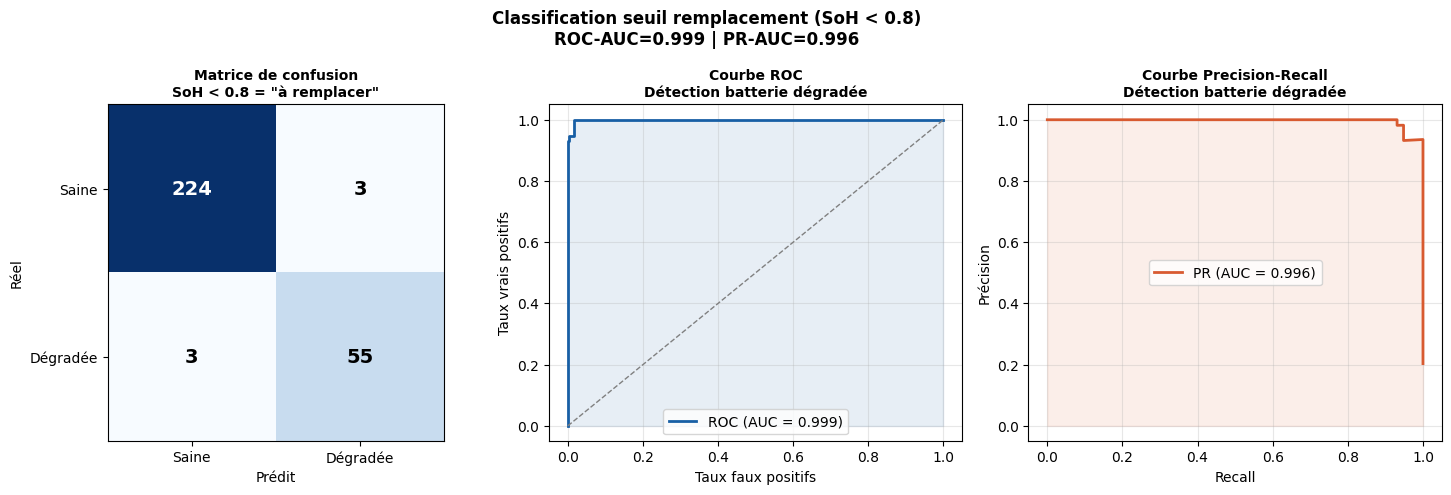

✅ Analyse seuil de remplacement sauvegardée


In [18]:
# ============================================================
# CELL 18 — REPLACEMENT THRESHOLD CLASSIFIER (SoH < 0.80)
# ============================================================
# Transforms the continuous SoH regression into a binary decision:
#   Class 1 (Dégradée) : SoH < 0.80 → battery needs replacement
#   Class 0 (Saine)    : SoH ≥ 0.80 → battery still operational
#
# The degradation score used for ROC/PR is 1 – SoH_pred:
#   higher score = model is more confident the battery is degraded.
#
# Metrics:
#   ROC-AUC : ability to rank degraded above healthy batteries
#   PR-AUC  : precision-recall balance (important with class imbalance)
#   Confusion matrix: False Negatives (missed degraded) are most costly
#                     in maintenance applications.
#
# Note: the threshold 0.80 is industry-standard for Li-ion batteries.
# A lower threshold (e.g. 0.75) reduces false alarms at the cost of
# missing some truly degraded units.
# ============================================================

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, precision_recall_curve)

print("="*60)
print("DÉTECTION SEUIL REMPLACEMENT — SoH < 0.8")
print("="*60)

THRESHOLD = 0.80
fusion_model.eval()
all_preds_raw, all_labels_raw = [], []
with torch.no_grad():
    for imgs, feats, labels in test_loader:
        imgs, feats = imgs.to(device), feats.to(device)
        preds = fusion_model(imgs, feats)
        all_preds_raw.extend(preds.cpu().numpy())
        all_labels_raw.extend(labels.numpy())

all_preds_raw  = np.array(all_preds_raw)
all_labels_raw = np.array(all_labels_raw)

y_true_bin = (all_labels_raw < THRESHOLD).astype(int)
y_pred_bin = (all_preds_raw  < THRESHOLD).astype(int)
y_score    = 1 - all_preds_raw

print("\nRapport de classification :")
print(classification_report(y_true_bin, y_pred_bin,
                             target_names=['Saine (≥0.8)', 'Dégradée (<0.8)']))

cm          = confusion_matrix(y_true_bin, y_pred_bin)
fpr, tpr, _ = roc_curve(y_true_bin, y_score)
roc_auc     = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(y_true_bin, y_score)
pr_auc       = auc(rec, prec)

print(f"\nROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im = axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
axes[0].set_title('Matrice de confusion\nSoH < 0.8 = "à remplacer"',
                   fontweight='bold', fontsize=10)
axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel')
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Saine','Dégradée'])
axes[0].set_yticklabels(['Saine','Dégradée'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center',
                     fontsize=14, fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')

axes[1].plot(fpr, tpr, color='#185FA5', linewidth=2,
             label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0,1],[0,1],'--', color='gray', linewidth=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#185FA5')
axes[1].set_xlabel('Taux faux positifs')
axes[1].set_ylabel('Taux vrais positifs')
axes[1].set_title('Courbe ROC\nDétection batterie dégradée',
                   fontweight='bold', fontsize=10)
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(rec, prec, color='#D85A30', linewidth=2,
             label=f'PR (AUC = {pr_auc:.3f})')
axes[2].fill_between(rec, prec, alpha=0.1, color='#D85A30')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Précision')
axes[2].set_title('Courbe Precision-Recall\nDétection batterie dégradée',
                   fontweight='bold', fontsize=10)
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle(f'Classification seuil remplacement (SoH < {THRESHOLD})\n'
             f'ROC-AUC={roc_auc:.3f} | PR-AUC={pr_auc:.3f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/replacement_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Analyse seuil de remplacement sauvegardée")



INCERTITUDE — Monte Carlo Dropout
Couverture intervalle 95% : 91.6%  (idéal ≥ 95%)
Largeur moyenne intervalle : 3.86%  (±1.93%)


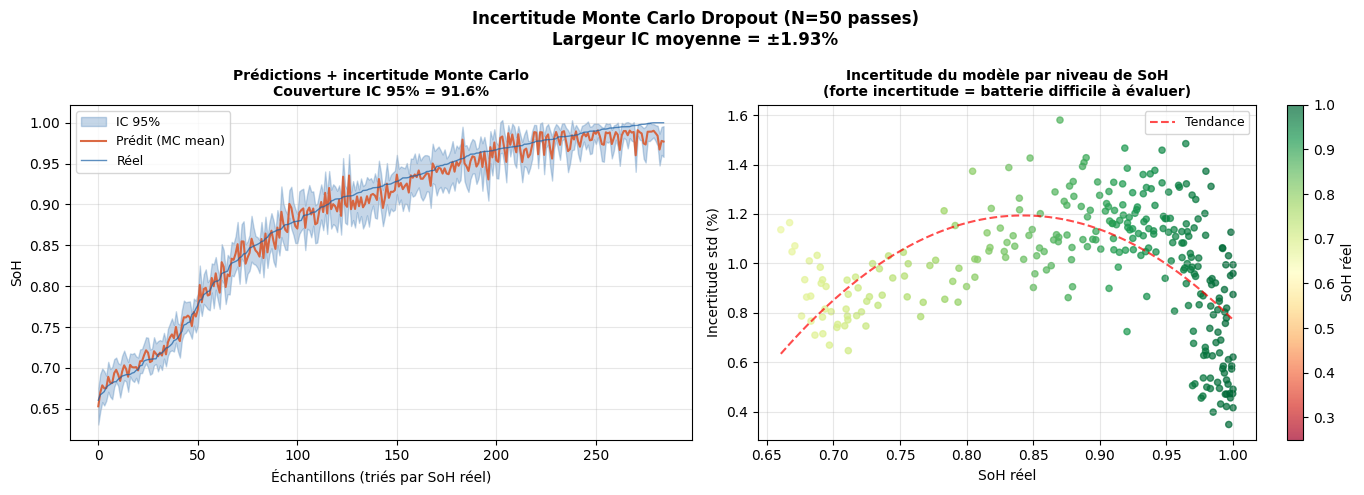


✅ Analyse d'incertitude sauvegardée

RÉCAPITULATIF FINAL — TOUS LES FICHIERS GÉNÉRÉS
  ✓ ablation_study.png                       Ablation: CSV-only vs Image-only vs Fusion
  ✓ baseline_comparison.png                  Baseline: RF/Ridge/GBM vs FusionModelV2
  ✓ degradation_curves.png                   Courbes de dégradation par batterie
  ✓ replacement_threshold.png                ROC/PR curve + matrice confusion SoH<0.8
  ✓ uncertainty_mc_dropout.png               Incertitude MC Dropout (IC 95%)


In [19]:
# ============================================================
# CELL 19 — UNCERTAINTY ESTIMATION (Monte Carlo Dropout)
# ============================================================
# MC Dropout (Gal & Ghahramani, 2016) approximates a Bayesian neural
# network by keeping Dropout active at inference time.
#
# Protocol:
#   N_MC = 50 stochastic forward passes through the full model.
#   For each pass, Dropout randomly zeros activations, producing a
#   different prediction. The distribution of predictions approximates
#   the posterior predictive distribution.
#
#   mc_mean  = mean prediction across 50 passes   (point estimate)
#   mc_std   = standard deviation                 (epistemic uncertainty)
#   IC 95%   = mc_mean ± 1.96 * mc_std
#
# Interpretation:
#   - High uncertainty → model is unsure (likely near decision boundary
#     or an unusual degradation pattern not well covered in training)
#   - Low uncertainty → model is confident (typical cycle, well-covered
#     by training data)
#
# Expected pattern: uncertainty tends to increase for batteries near the
# replacement threshold (SoH ≈ 0.80) where the prediction is most critical.
# ============================================================

print("="*60)
print("INCERTITUDE — Monte Carlo Dropout")
print("="*60)

def enable_dropout(model):
    """Activates Dropout layers even in eval mode."""
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

N_MC = 50
fusion_model.eval()
enable_dropout(fusion_model)

mc_preds = []
with torch.no_grad():
    for _ in range(N_MC):
        batch_preds = []
        for imgs, feats, labels in test_loader:
            imgs, feats = imgs.to(device), feats.to(device)
            batch_preds.extend(fusion_model(imgs, feats).cpu().numpy())
        mc_preds.append(batch_preds)

mc_preds = np.array(mc_preds)   # (N_MC, N_test)
mc_mean  = mc_preds.mean(axis=0)
mc_std   = mc_preds.std(axis=0)
mc_lower = mc_mean - 1.96 * mc_std
mc_upper = mc_mean + 1.96 * mc_std

fusion_model.eval()  # reset Dropout to eval mode

coverage      = np.mean((all_labels_raw >= mc_lower) & (all_labels_raw <= mc_upper)) * 100
mean_interval = (mc_upper - mc_lower).mean() * 100
print(f"Couverture intervalle 95% : {coverage:.1f}%  (idéal ≥ 95%)")
print(f"Largeur moyenne intervalle : {mean_interval:.2f}%  (±{mean_interval/2:.2f}%)")

sort_idx = np.argsort(all_labels_raw)
true_s   = all_labels_raw[sort_idx]
mean_s   = mc_mean[sort_idx]
lower_s  = mc_lower[sort_idx]
upper_s  = mc_upper[sort_idx]
std_s    = mc_std[sort_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].fill_between(range(len(true_s)), lower_s, upper_s,
                      alpha=0.25, color='#185FA5', label='IC 95%')
axes[0].plot(mean_s, color='#D85A30', linewidth=1.5,
             label='Prédit (MC mean)', alpha=0.9)
axes[0].plot(true_s, color='#185FA5', linewidth=1,
             label='Réel', alpha=0.7)
axes[0].set_xlabel('Échantillons (triés par SoH réel)')
axes[0].set_ylabel('SoH')
axes[0].set_title(f'Prédictions + incertitude Monte Carlo\nCouverture IC 95% = {coverage:.1f}%',
                   fontweight='bold', fontsize=10)
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

scatter = axes[1].scatter(true_s, std_s * 100,
                           c=true_s, cmap='RdYlGn',
                           s=20, alpha=0.7, vmin=0.25, vmax=1.0)
plt.colorbar(scatter, ax=axes[1], label='SoH réel')
axes[1].set_xlabel('SoH réel')
axes[1].set_ylabel('Incertitude std (%)')
axes[1].set_title('Incertitude du modèle par niveau de SoH\n'
                   '(forte incertitude = batterie difficile à évaluer)',
                   fontweight='bold', fontsize=10)
axes[1].grid(alpha=0.3)
z = np.polyfit(true_s, std_s * 100, 2)
p = np.poly1d(z)
x_line = np.linspace(true_s.min(), true_s.max(), 200)
axes[1].plot(x_line, p(x_line), 'r--', linewidth=1.5, alpha=0.7, label='Tendance')
axes[1].legend(fontsize=9)

plt.suptitle(f'Incertitude Monte Carlo Dropout (N={N_MC} passes)\n'
             f'Largeur IC moyenne = ±{mean_interval/2:.2f}%',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/uncertainty_mc_dropout.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================================
# FINAL SUMMARY — OUTPUTS
# ============================================================

print("\n✅ Analyse d'incertitude sauvegardée")
print("\n" + "="*60)
print("RÉCAPITULATIF FINAL — TOUS LES FICHIERS GÉNÉRÉS")
print("="*60)

files = [
    ('ablation_study.png',          'Ablation: CSV-only vs Image-only vs Fusion'),
    ('baseline_comparison.png',     'Baseline: RF/Ridge/GBM vs FusionModelV2'),
    ('degradation_curves.png',      'Courbes de dégradation par batterie'),
    ('replacement_threshold.png',   'ROC/PR curve + matrice confusion SoH<0.8'),
    ('uncertainty_mc_dropout.png',  'Incertitude MC Dropout (IC 95%)'),
]
for fname, desc in files:
    print(f"  ✓ {fname:<40} {desc}")